## Importação de biblioteca

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from scipy.stats import shapiro, probplot

import seaborn as sns 
import matplotlib.pyplot as plt


from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score


from sklearn.preprocessing import OneHotEncoder



## Carregamento de dados

In [2]:
path = Path(r'../data/raw/desafio_nps_fase_1.csv')

In [3]:
df = pd.read_csv(path)

### Variaveis

In [4]:
#barplot
nps_map = {1: 'Detratores', 2: 'Passivo', 3: 'Promotores'}


cores_nps = {
    "Detratores": "#E74C3C", # Vermelho
    "Passivo": "#F1C40F",    # Amarelo
    "Promotores": "#27AE60"  # Verde
}

dicionario_colunas = {
    'complaints_count' :'numero de reclamações',
    'delivery_delay_days':'dias de atraso',
    'customer_service_contacts':'numero de contatos com atendimento',
    'resolution_time_days':'dias para resolução',
    'nps_score':'NPS',
    'nps_cat' : 'categoria de nps'
    
}

### Funções 

In [5]:
#Categorias 

def nps_class(df):
    if df['nps_score'] <= 6:
        return 'detractors'
    elif df['nps_score'] < 9:
        return 'passives'
    else:
        return 'promoter'

In [6]:

# Diretório padrão

target_dir = Path("../docs/images")
target_dir.mkdir(parents=True, exist_ok=True)


# Função de salvar

def salvar_fig(fig, nome_arquivo, show=True):
    fig.tight_layout()
    fig.savefig(target_dir / nome_arquivo, bbox_inches='tight', dpi=300)
    
    if show:
        plt.show()
    
    plt.close(fig)



# KDE PLOT

def gerar_kdeplot(df, x):
    fig, ax = plt.subplots(figsize=(10, 6))

    df_plot = df.assign(nps_labels=df['nps_cat'].map(nps_map))
    
    sns.kdeplot(
        data=df_plot,
        x=x,
        hue='nps_labels',
        palette=cores_nps,
        fill=True,
        bw_adjust=2,
        common_norm=False,
        ax=ax
    )
    
    ax.set_title(f'Tendência de Categorias NPS por {dicionario_colunas[x]}')
    ax.set_xlabel(dicionario_colunas[x])
    ax.set_ylabel('Densidade de Clientes')

    nome_arquivo = f"kde_{x}.png"
    salvar_fig(fig, nome_arquivo)



# HIST PLOT

def gerar_hisplot(df, x):
    # 1. Estilo "White" (totalmente limpo, sem nenhuma linha de grade)
    sns.set_theme(style="white")
    
    fig, ax = plt.subplots(figsize=(12, 6))

    df_plot = df.assign(nps_labels=df['nps_cat'].map(nps_map))
    
    sns.histplot(
        data=df_plot,
        x=x,
        hue='nps_labels',
        palette=cores_nps,
        multiple="stack",
        discrete=True,
        shrink=0.8,
        edgecolor='white',
        linewidth=1.5,
        alpha=0.9,
        ax=ax
    )
    
    # 2. Adicionando os Rótulos de Dados (A Mágica)
    for container in ax.containers:
        # Pega a altura de cada pedacinho da barra. Se for 0, deixa vazio para não poluir o gráfico.
        labels = [f'{v.get_height():.0f}' if v.get_height() > 0 else '' for v in container]
        
        # Insere o número bem no centro da cor correspondente
        ax.bar_label(container, labels=labels, label_type='center', 
                     color='white', fontweight='bold', fontsize=11)
    
    # 3. Textos do Gráfico
    ax.set_title(f'Tendência de NPS por {dicionario_colunas[x].title()}', 
                 fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel(dicionario_colunas[x].title(), fontsize=13, fontweight='bold')
    
    # 4. Limpeza Extrema (Removendo o Eixo Y por completo)
    ax.set_ylabel('') # Tira o texto "Quantidade de Clientes"
    ax.get_yaxis().set_visible(False) # Esconde os números laterais (0, 100, 200...)
    sns.despine(left=True, bottom=True) # Remove a linha preta do chão e da parede
    
    # 5. Legenda
    if ax.get_legend() is not None:
        ax.get_legend().set_title(None)
        sns.move_legend(ax, "upper right", bbox_to_anchor=(1.15, 1))

    nome_arquivo = f"hist_{x}.png"
    salvar_fig(fig, nome_arquivo)



# LINHAS PERCENTUAIS

def grafico_linhas_percentual(df, coluna):
    df_trend = pd.crosstab(df[coluna], df['nps_cat'], normalize='index') * 100
    df_trend.columns = nps_map.values()
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    df_trend.plot(
        kind='line',
        marker='o',
        color=cores_nps,
        ax=ax
    )
    
    ax.set_title(f'Percentual de Categorias NPS conforme {dicionario_colunas[coluna]}')
    ax.set_ylabel('% de Clientes')
    ax.set_xlabel(dicionario_colunas[coluna])
    ax.grid(alpha=0.3)

    nome_arquivo = f"linhas_{coluna}.png"
    salvar_fig(fig, nome_arquivo)



# DISTRIBUIÇÃO + IC

def analyze_distribution_and_ci(data, confidence=0.95, n_bootstrap=5000):
    data = np.array(data)
    n = len(data)
    mean = np.mean(data)

    # Teste de normalidade
    _, shapiro_p = shapiro(data)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Histograma
    axes[0].hist(data, bins=10)
    axes[0].set_title("Histograma")

    # QQ-Plot
    probplot(data, dist="norm", plot=axes[1])
    axes[1].set_title("QQ-Plot")

    salvar_fig(fig, "distribuicao_ci.png")

    # Bootstrap
    alpha = 1 - confidence
    boot_means = []

    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=n, replace=True)
        boot_means.append(np.mean(sample))

    lower = np.percentile(boot_means, (alpha/2) * 100)
    upper = np.percentile(boot_means, (1 - alpha/2) * 100)

    print(f"Média da amostra: {mean:.3f}")
    print(f"IC Bootstrap ({confidence*100:.0f}%): {lower:.3f} a {upper:.3f}")
    print(f"p-valor Shapiro-Wilk: {shapiro_p:.4f} {'(normal)' if shapiro_p>0.05 else '(não normal)'}")

### Qualidade dos Dados

In [7]:
df.shape

(2500, 19)

In [8]:
df.dtypes

customer_id                    int64
customer_age                   int64
customer_region               object
customer_tenure_months         int64
order_id                       int64
order_value                  float64
items_quantity                 int64
discount_value               float64
payment_installments           int64
delivery_time_days             int64
delivery_delay_days            int64
freight_value                float64
delivery_attempts              int64
customer_service_contacts      int64
resolution_time_days           int64
nps_score                    float64
repeat_purchase_30d            int64
complaints_count               int64
csat_internal_score          float64
dtype: object

In [9]:
df.isnull().sum().sum()

0

### Classificação de NPS

Começaremos arredondando os valores de NPS, para não trabalharmos com numeros com pontos fluantes

Classificaremos os NPS  

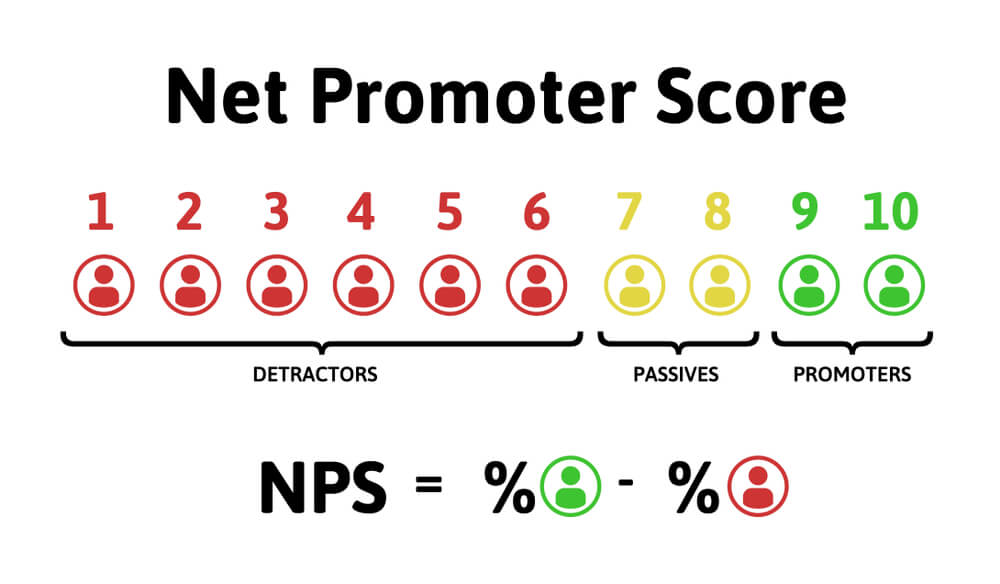

In [10]:
df['classificacao_nps'] = df.apply(nps_class,axis=1)
df['classificacao_nps'].value_counts().to_frame().assign(pct=df['classificacao_nps'].value_counts(1)*100)

,count,pct
classificacao_nps,,
detractors,1851,74.04
passives,539,21.56
promoter,110,4.40


Nossa base demonstra 74% dos clientes como detratores, apenas 4% como promotores. 

In [11]:
#removendo da base colunas que nao serão necessárias
df_nps = df.drop(columns={'customer_id','csat_internal_score','classificacao_nps'})

**Categorizando as regiões com o one-hot encoder**

In [12]:
df_nps['customer_region'].unique()

array(['Nordeste', 'Sul', 'Centro-Oeste', 'Norte', 'Sudeste'],
      dtype=object)

In [13]:
region_cat = df_nps[['customer_region']]

try:
    from sklearn.preprocessing import OneHotEncoder
except ImportError:
    from future_encoders import OneHotEncoder # Scikit-Learn < 0.20

cat_encoder = OneHotEncoder()
region_cat_1hot = cat_encoder.fit_transform(region_cat)
region_cat_1hot

<2500x5 sparse matrix of type '<class 'numpy.float64'>'
	with 2500 stored elements in Compressed Sparse Row format>

Vamos transformar as colunas categiruas em numericas para conseguirmos fazer analises posteriores


In [14]:
# Transformando a coluna em categoria e extraindo o código numérico
df_nps['customer_region_encoded'] = df_nps['customer_region'].astype('category').cat.codes

region_mapping = dict(enumerate(df_nps['customer_region'].astype('category').cat.categories))
df_nps.drop(columns=['customer_region'], axis=1, inplace=True)
print(f"Mapeamento: {region_mapping}")

Mapeamento: {0: 'Centro-Oeste', 1: 'Nordeste', 2: 'Norte', 3: 'Sudeste', 4: 'Sul'}


In [15]:
#df_nps['nps_score'] = np.round(df_nps["nps_score"])
#df_nps['nps_score'] = np.ceil(df_nps["nps_score"]) 
# ### o ceil e o round afastam muito o modelo da base inicial por isso optei por remove-los e assim manter maior proximidade da base original

In [16]:
df_nps.head(2)

,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,customer_region_encoded
0,63,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,1
1,20,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,4


---

## Explorando o problema

**Pergunta principal**
> quais fatores operacionais realmente influenciam a satisfação do cliente ? <br>
como a empresa pode agir de forma proativa para melhorar a experiência antes mesmo da
aplicação da pesquisa de NPS?

### 1.Entendimento do negócio:

**Qual problema de negócio está sendo resolvido?** <br>
>Precisamos antecipar o resultado do NPS antes da pesquisa acontecer, atualmente nossa empresa só descobre se o atendimento foi ruim tarde demais. O problema que estamos resolvendo é como transformar os dados operacionais (de logistica e atendimento principalmente ) em insights preditivos podendo assim antecipar a dor dos nossos clientes e agir de forma preditiva antes para conseguirmos induzir uma melhor nota de NPS

**Por que o NPS é importante para um e-commerce?**
> um NPS é importante por se tratar de uma métrica de satisfação dos clientes, a partir disso podemos avaliar a experiencia de nossos clientes tendo assim uma referencia da qualidade de nossos serviços, uma experiencia positiva pode afetar diretamente a receita através da recompra e fidelização dos clientes, custos por evitar retrabalho de logistica e/ou atendimentos especificos. uma alta NPS também é um sinal da reputação de nossa empresa o que ajuda a atrair novos clientes 

**Quais áreas poderiam se beneficiar desses insights?**

*podemos receber diversos benefios ao criar uma cultura voltada ao NPS* <br>
>- **Logistico:** analisar os atrasos e pensar em estratégias para diminuir o tempo de entrega <br>
>- **Atendimento ao cliente:** um numero de NPS maior indica menos contatos de resolução de problemas, acarretando indiretamente em menor tempo de resolução de problemas.  <br>
> - **Marketing:** ao identificarmos clientes promotores poderiamos por exemplo, criar programas de indicação de clientes com benefios, a experiencia positiva dos promotores pode ser uma alavanca importante para a divulgação dos nossos serviços, também poderiamos oferecer cupons de desconto para clientes de alto risco para tentar minimizar os danos. <br> 

### 1.1 impactos do NPS <br>

**Recompra** <br>
> recompra está diretamente relacionada aos promotores
> Churn está diretamente relacionado aos detratadores
<br>

**Boca a boca** <br>
> promotores podem gerar divulgação de nossos serviços de forma organica
> detratores podem gerar uma reputação negativa de nosso serviços impedindo de alcançarmos novos clientes
<br>


**Market share em e-commerce**<br>
> quanto melhor a experiencia de nossos clientes maior será o nosso market share, principalmente por se tratar de um e-commerce, esse setor especifico está a um clique de distancia de uma troca de fornecedores. 

**Quais indicadores de mercado poderiam complementar essa análise? Exemplos: benchmarks de NPS, SLA logístico, concorrência.**


> **Benchmarks de NPS:** Comparar o nosso NPS com a média do setor de e-commerce nacional ajuda a entender se estamos performando acima ou abaixo do mercado. Um NPS absoluto pode parecer baixo, mas pode estar acima da média da indústria.
> 
> **SLA Logístico (Service Level Agreement) do Mercado:** Monitorar o prazo médio de entrega dos principais players. Se os concorrentes entregam em 2 dias e nós em 5, mesmo sem atraso técnico, a expectativa do cliente será frustrada, impactando o NPS negativamente.
> 
> **Análise de Concorrência:** Avaliar as facilidades de devolução, campanhas promocionais e qualidade de pós-venda dos concorrentes diretos, que influenciam na percepção de valor e nível de exigência dos nossos clientes.
> 
> **Custo de Aquisição de Clientes (CAC) e Lifetime Value (LTV):** Conectar o NPS com CAC e LTV permite estimar o impacto financeiro real da perda de detratores e do valor gerado pelos promotores a longo prazo.

### 2. Definição da Target:


**Qual variável representa a satisfação do cliente?** <br>
> nps_score foi a métrica escolhida como nosso target, posteriormente foi simplificada para nps_cat que categoriza os nps como 'promotores, passivos e detratores'
<br>

**Por que ela foi escolhida?** <br>
> é uma métrica mundialmente utilizada gerada através de pesquisas, uma informação vinda dos próprios clientes é o indicador final de satisfação e lealdade.
<br>

**Em que momento da jornada essa informação é coletada?** <br>
> ao fim da jornada de compras, no pós atendimento
<br>

**Existe algum risco de usar essa variável de forma inadequada?** <br>
> não temos a resposta de todos os clientes, normalmente teremos os maiores detratores ou promotores, os clientes que dão notas geralmente são ligados por algum critério, devemos entender isso além de não conseguir trazer toda a experiencia de nossos clientes em resumo o NPS ainda que seja importante é uma variavel simplificada

# 3. Análise Exploratória dos Dados (EDA)


● Que tipo de cliente tende a ter NPS mais alto ou mais baixo? <br>

#### **Quais fatores parecem mais críticos para a satisfação?**

faremos uma analise utilizando corr para identificar uma associação linear direta entre as notas de nps como um todo

In [17]:
correlacoes = df_nps.corr()['nps_score'].sort_values(ascending=True)
correlacoes

delivery_delay_days         -0.597260
complaints_count            -0.496800
customer_service_contacts   -0.350845
resolution_time_days        -0.191392
freight_value               -0.041087
customer_age                -0.009936
customer_tenure_months      -0.009711
delivery_time_days           0.000925
items_quantity               0.011468
order_id                     0.015162
payment_installments         0.023718
discount_value               0.025104
delivery_attempts            0.027680
customer_region_encoded      0.028502
order_value                  0.036990
repeat_purchase_30d          0.570324
nps_score                    1.000000
Name: nps_score, dtype: float64

In [18]:
print('variaveis com maior probabilidade de afetar a satisfação')
correlacoes[abs(correlacoes) > 0.15]

variaveis com maior probabilidade de afetar a satisfação


delivery_delay_days         -0.597260
complaints_count            -0.496800
customer_service_contacts   -0.350845
resolution_time_days        -0.191392
repeat_purchase_30d          0.570324
nps_score                    1.000000
Name: nps_score, dtype: float64

#### **O que mais gera detratores? <br>**

para responder essa pergunta primeiro vamos categorizar as nps <br>
> 1 detratores
 2 passivos
 3 promotores

In [19]:
df_nps["nps_cat"] = pd.cut(df_nps["nps_score"],
                               bins=[-1,6 , 8, 10],
                               labels=[1, 2, 3])

In [20]:
print('nova associação, mas agora quanto relação das categoria do NPS')
nps_cat = df_nps.corr()['nps_cat'].sort_values(ascending=True)
nps_cat[:4]

nova associação, mas agora quanto relação das categoria do NPS


complaints_count            -0.443605
delivery_delay_days         -0.412236
customer_service_contacts   -0.246885
resolution_time_days        -0.158034
Name: nps_cat, dtype: float64

agora faremos uma analise utilizando as médias por grupos.<br>

In [21]:
#dataframe agrupado por categoria 
comparativo = df_nps.groupby('nps_cat',observed=False).mean()

o objetivo dessa analise é entender as maiores correlações entre os detratores  <br>
para isso iremos agrupar e faremos uma média de todos os dados, após isso iremos filtrar apenas os detratores [1]

In [22]:
perfil_detrator = comparativo.loc[1] / comparativo.median() 
perfil_detrator = perfil_detrator.sort_values(ascending=False)

print(perfil_detrator[:4])

delivery_delay_days          1.816590
complaints_count             1.547879
customer_service_contacts    1.500020
resolution_time_days         1.198866
dtype: float64


apenas para fim de estudos veremos as relações entre os promotores também

In [23]:
perfil_promotor = comparativo.loc[3] / comparativo.median() 
perfil_promotor = perfil_promotor.sort_values(ascending=False)

print(perfil_promotor[:4])

repeat_purchase_30d        26.352941
nps_score                   1.319315
discount_value              1.068651
customer_region_encoded     1.065840
dtype: float64


#### <font size="5"> **Estudo de ruptura em contato do cliente** </font>

##### <font size="5">**Ruptura em numero de reclamações**</font>

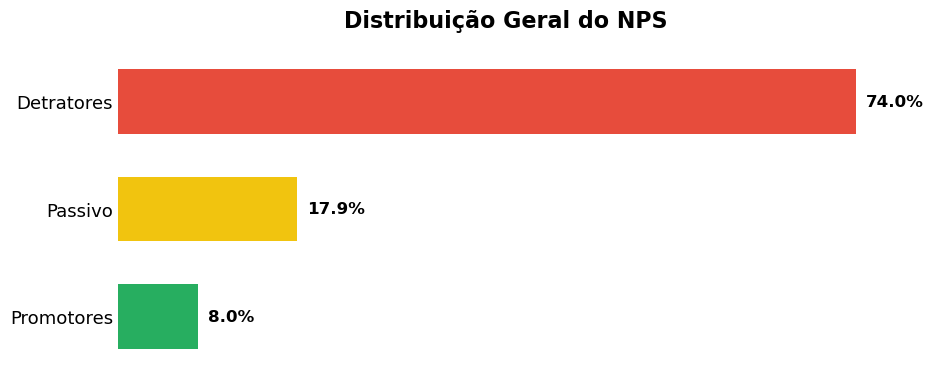

In [24]:
distribuicao_nps = df_nps['nps_cat'].map(nps_map).value_counts(normalize=True) * 100

ordem = ['Promotores', 'Passivo', 'Detratores']
distribuicao_nps = distribuicao_nps.reindex(ordem)

fig, ax = plt.subplots(figsize=(10, 4))

fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

cores_barras = [cores_nps[categoria] for categoria in distribuicao_nps.index]
bars = ax.barh(distribuicao_nps.index, distribuicao_nps.values, color=cores_barras, height=0.6)

for bar in bars:
    largura = bar.get_width()
    ax.text(largura + 1, bar.get_y() + bar.get_height() / 2, 
            f'{largura:.1f}%', 
            va='center', ha='left', color='black', fontweight='bold', fontsize=12)


ax.set_title('Distribuição Geral do NPS', fontsize=16, fontweight='bold', pad=20)
ax.get_xaxis().set_visible(False) # Remove o eixo X inferior
sns.despine(left=True, bottom=True) # Remove linhas pretas
ax.tick_params(axis='y', length=0, labelsize=13) # Remove o "tracinho" do eixo Y e aumenta a fonte

target_dir = Path("../docs/images")
plt.savefig(target_dir / "distribuicao_nps_transparente.png", transparent=True, bbox_inches='tight', dpi=300)

plt.show()


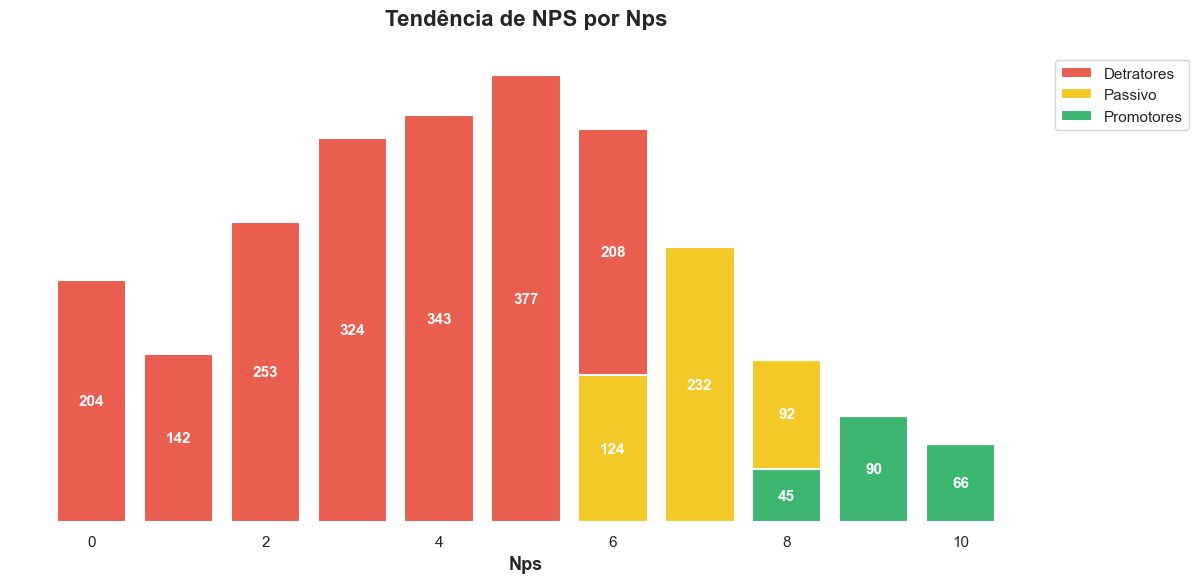

In [25]:
# as barras divididas ao meio tratam os numeros flutuantes, em 6 existem mais detratores que promotores... 

gerar_hisplot(df_nps,'nps_score')

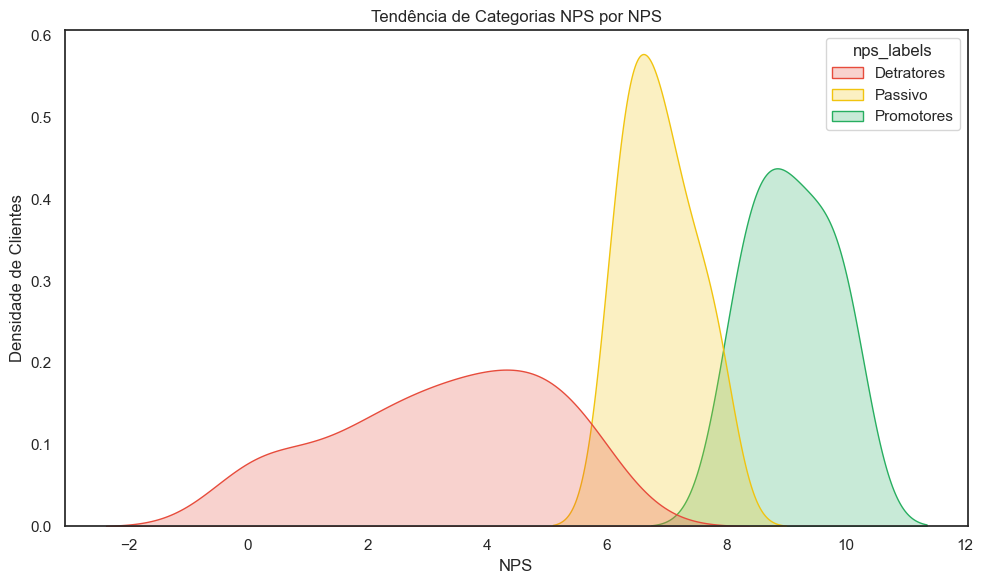

In [26]:
gerar_kdeplot(df_nps,'nps_score')

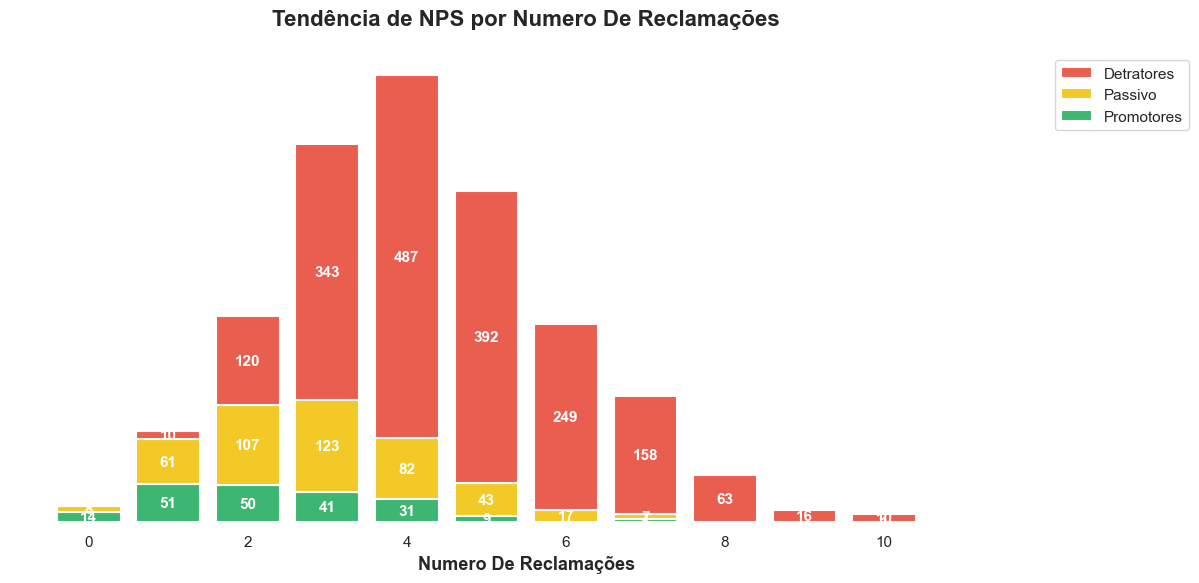

In [27]:
#histplot
gerar_hisplot(df_nps,'complaints_count')

> ao analisar a quantidade de reclamações é possivel notar uma tendencia de maior numero de detratores a partir da terceira reclamação 

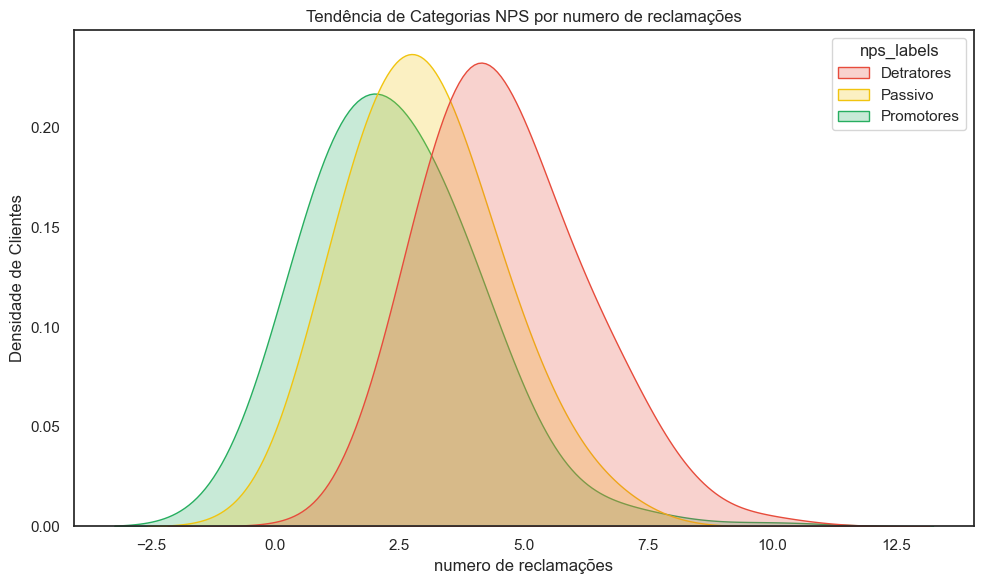

In [28]:
gerar_kdeplot(df_nps,'complaints_count')

> novamente identificamos um ponto de transição a partir de três reclamações,
aqui é onde o numero de detratores supera o numero de promotores e o ponto de ruptura aparenta ser a quarta reclamação,
onde o numero de promotores passa a ser substancialmente menor que o numero de detratores
vamos fazer agora uma analise percentual de nps por numero de reclamações

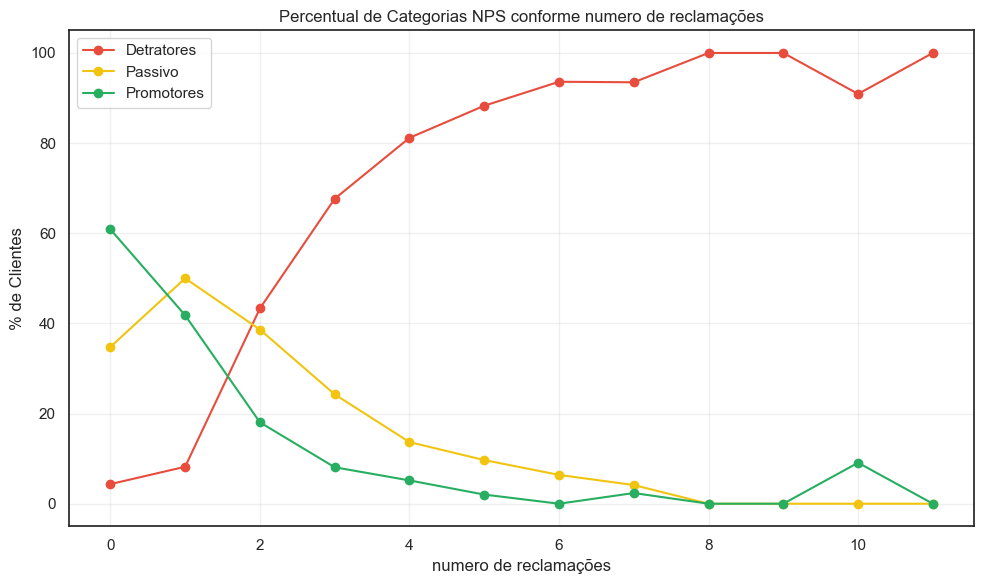

In [29]:
grafico_linhas_percentual(df_nps,'complaints_count')

> Em termos percentuais o numero de detratores supera os promotores a partir da segunda reclamação. 

##### <font size="5">**Ruptura em dias de atraso**</font>

faremos uma analise de contagem geral das categorias em relação ao dia de atrasos

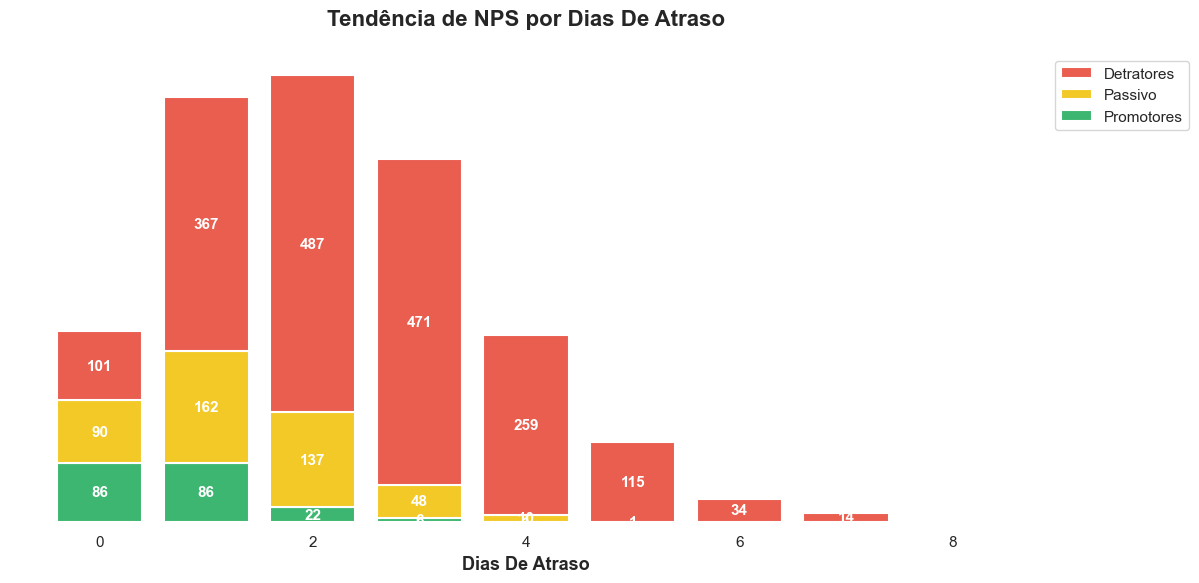

In [30]:
gerar_hisplot(df_nps,'delivery_delay_days')

podemos notar que a partir de 1 dia de atraso já temos um aumento substancial de detratores, e a partir do segundo dia de atraso o numero de promotores é quase nulo. 
agora vamos fazer uma analise de densidade 

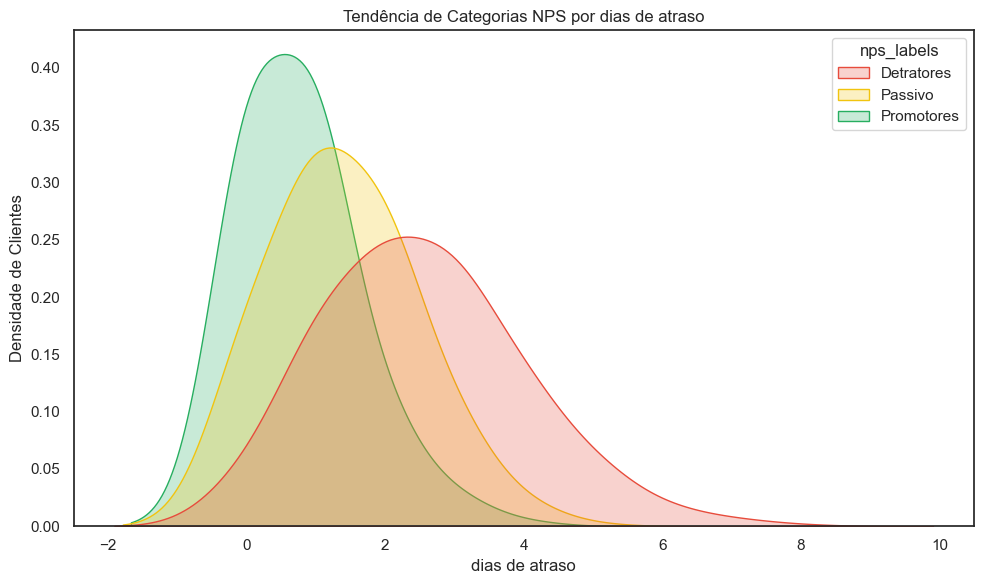

In [31]:
gerar_kdeplot(df_nps,'delivery_delay_days')

novamente identificamos um ponto de transição no segundo dia, aqui é onde o numero de detratores supera o numero de promotores e o ponto de ruptura aparenta ser o terceiro dia, onde o numero de promotores passa a ser bem baixo
vamos fazer agora uma analise percentual de nps por dia de atraso

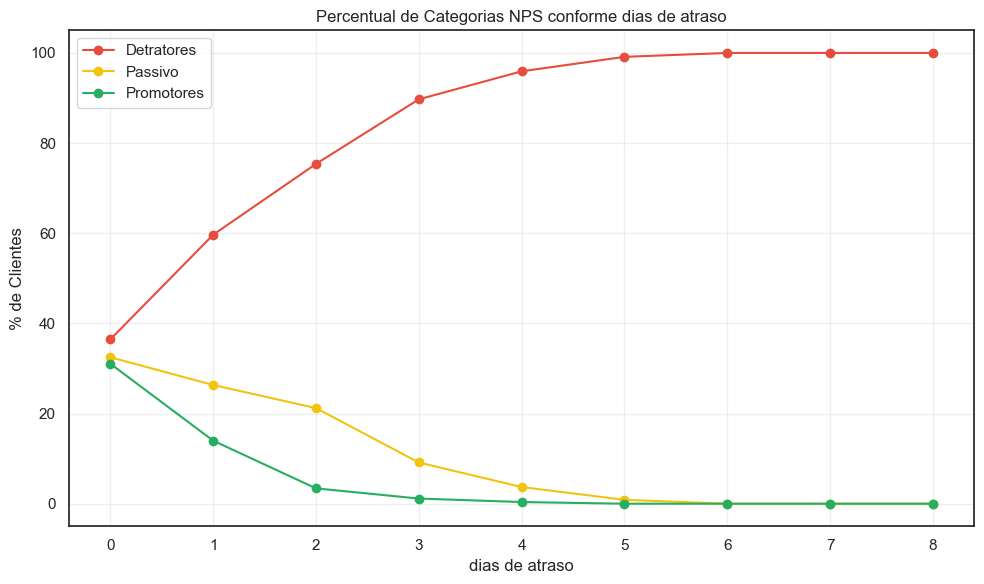

In [32]:
grafico_linhas_percentual(df_nps,'delivery_delay_days')

##### <font size="5">**Ruptura em numero de contatos**</font>

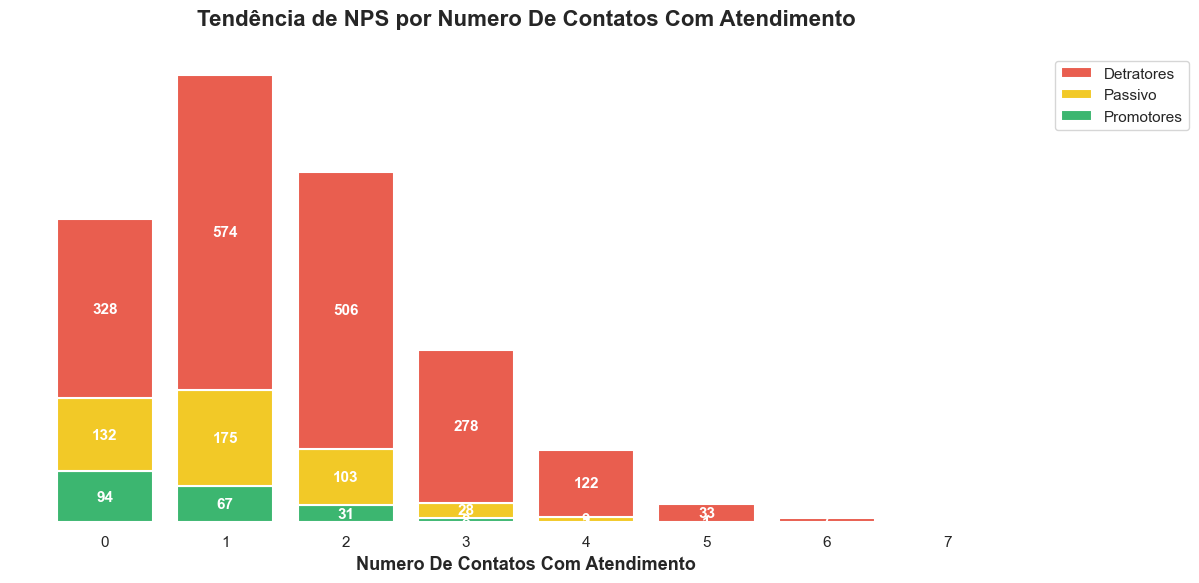

In [33]:
gerar_hisplot(df_nps,'customer_service_contacts')

Existe uma tendencia a detratores já no primeiro contato com nossa equipe de atendimento

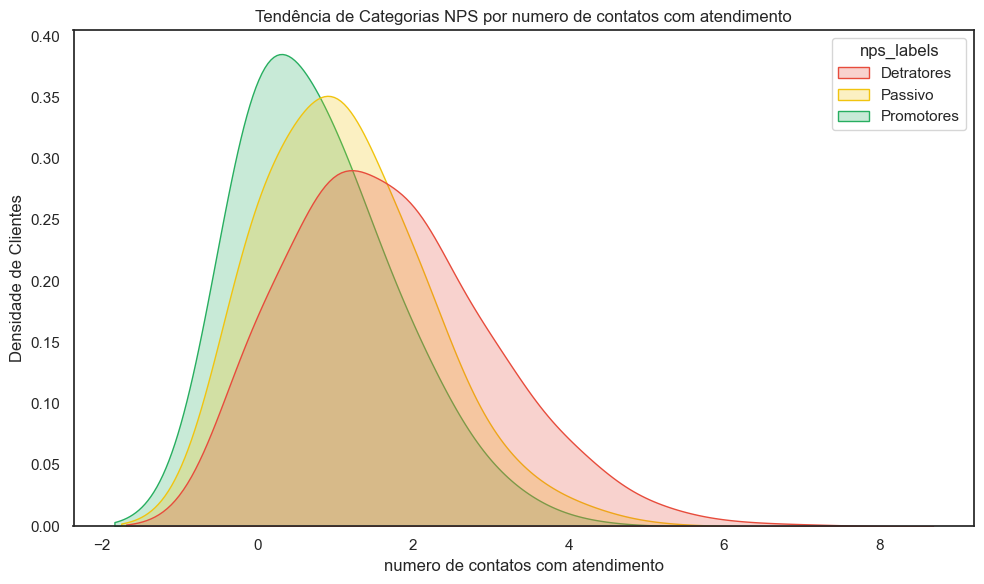

In [34]:
gerar_kdeplot(df_nps,'customer_service_contacts')

Podemos notar uma tendencia a promotores que entram em contato apenas uma vez com o SAC

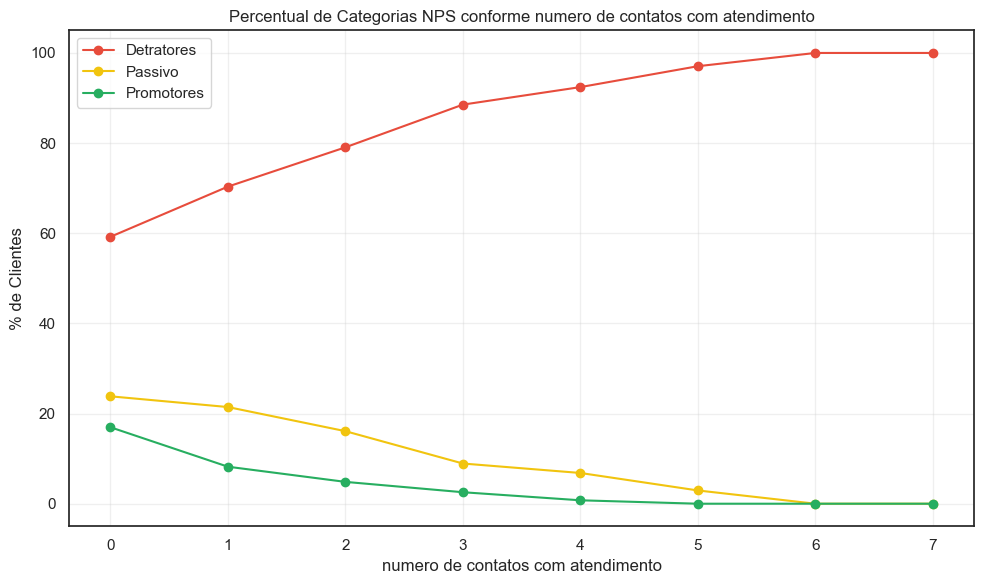

In [35]:
grafico_linhas_percentual(df_nps,'customer_service_contacts')

existe uma forte tendencia a detratores até mesmo antes de entrar em contato com atendimento. E conseguimos manter um percentual de passivos e promotores em torno de 40% se conseguirmos resolver o problema antes do segundo contato.

Vamos avaliar agora a ultima variavel com forte correlação

##### <font size="5">**Ruptura em em dias para a resolução de problemas**</font>

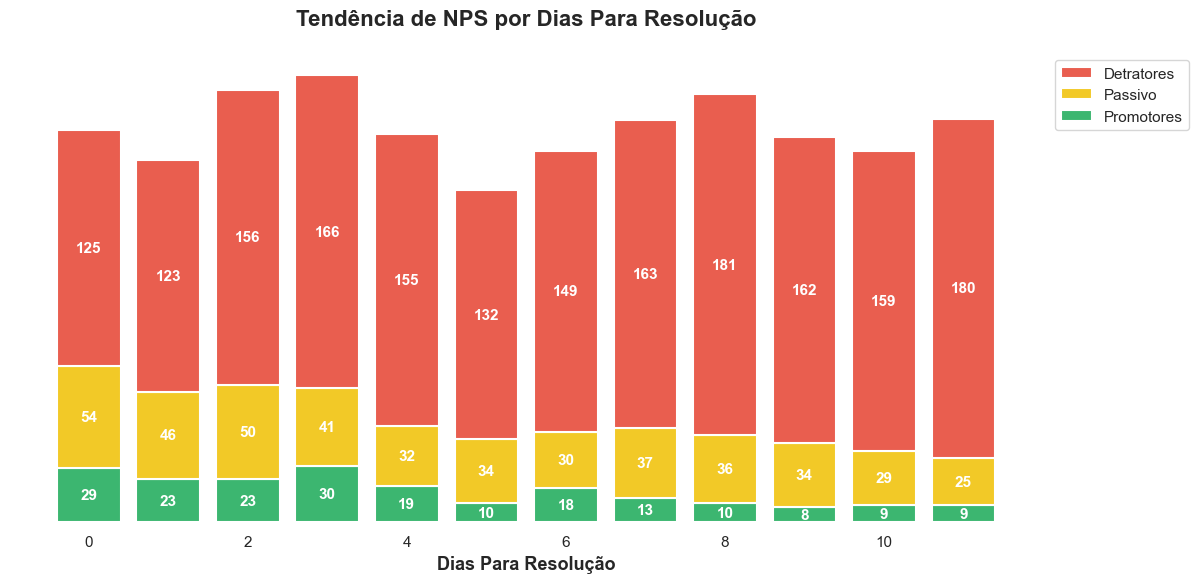

In [36]:
gerar_hisplot(df_nps,'resolution_time_days')

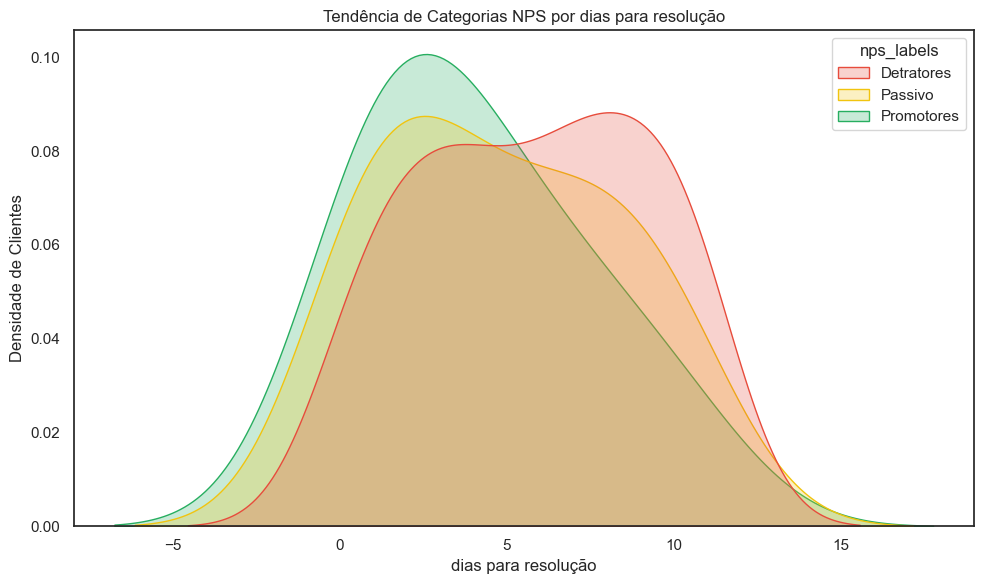

In [37]:
gerar_kdeplot(df_nps,'resolution_time_days')

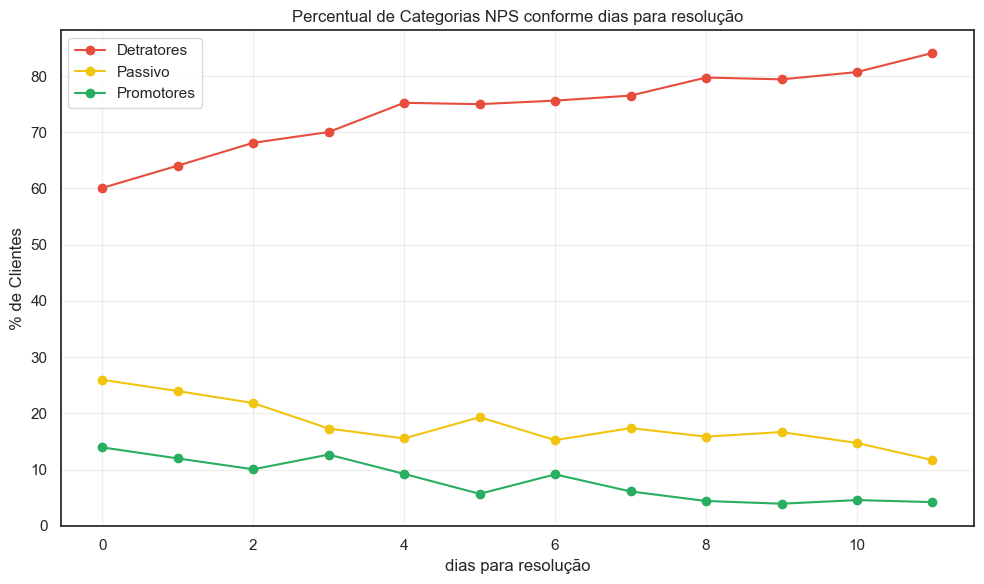

In [38]:
grafico_linhas_percentual(df_nps,'resolution_time_days')

Existe uma maior tendencia a se tornar detrator a partir de um atraso de 4 antes da resolução do problema   

#### <font size="6"> **Conclusão sobre os pontos de ruptura:** </font> <br>
**é possivel chegar a algumas hipóteses:** <br>
> a partir da terceira reclamação os clientes tem maior chance de se tornarem detratores<br>
> a partir do segundo dia de atraso os clientes tem maior probabilidade de se tornarem detratores <br>
> a partir do segundo contato existe maior probabilidade dos clientes se tornarem detratores <br>
> a partir do terceiro dia sem a resolução de problemas, existe uma maior probabilidade do cliente se tornar detrator <br>

#### <font size="5"> **Estudo de hipoteses** </font>

In [39]:
from scipy.stats import mannwhitneyu

def teste_mann_w_u(grupo_1, grupo_2,h0="",alpha=0.05 ):
    stat, p_value = mannwhitneyu(grupo_1, grupo_2, alternative='two-sided')

    
    print(f"Estatística U: {stat}")
    print(f"p-valor: {p_value}")
    
    if p_value < alpha:
        print('Resultado: Há diferença simgnificativa.')
        print(f"Rejeitamos a hipótese nula (H0): {h0}")
        
    else:
        print('Resultado: Não há diferença significativa.')
        print(f"Não rejeitamos a hipótese nula (H0). {h0} ")

##### <font size="5">h1 = a partir da terceira reclamação os clientes tem maior chance de se tornarem detratores</font>

In [40]:
hipotese_nula_reclamacoes = 'NPS se mantem igual com menos de três reclamações'
reclamacoes_h0 = df_nps[df_nps['complaints_count'] < 3]['nps_score']
reclamacoes_h1= df_nps[df_nps['complaints_count'] >= 3]['nps_score']

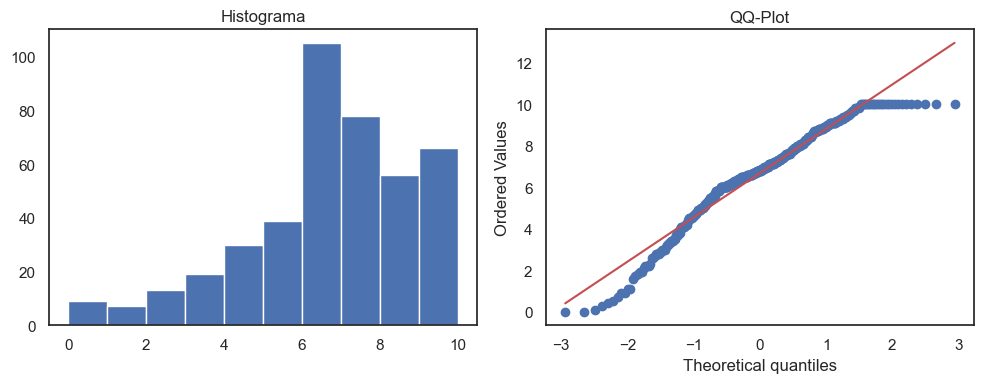

Média da amostra: 6.683
IC Bootstrap (95%): 6.475 a 6.881
p-valor Shapiro-Wilk: 0.0000 (não normal)


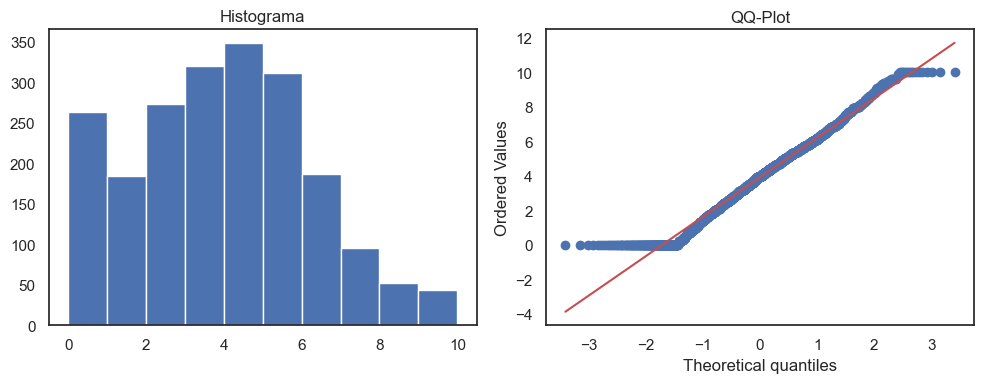

Média da amostra: 3.911
IC Bootstrap (95%): 3.813 a 4.008
p-valor Shapiro-Wilk: 0.0000 (não normal)


In [41]:
analyze_distribution_and_ci(reclamacoes_h0)
analyze_distribution_and_ci(reclamacoes_h1)

In [42]:
teste_mann_w_u(reclamacoes_h0,reclamacoes_h1,hipotese_nula_reclamacoes)

Estatística U: 713910.5
p-valor: 2.558867076207088e-92
Resultado: Há diferença simgnificativa.
Rejeitamos a hipótese nula (H0): NPS se mantem igual com menos de três reclamações


##### <font size="5">h1 = a partir do 2º dia de atraso os clientes tem maior probabilidade de se tornarem detratores </font>

In [43]:
hipotese_nula_atraso = 'NPS se mantem igual com até dois dias de atraso'
atraso_h0 = df_nps[df_nps['delivery_delay_days'] < 3]['nps_score']
atraso_h1= df_nps[df_nps['delivery_delay_days'] >= 3]['nps_score']

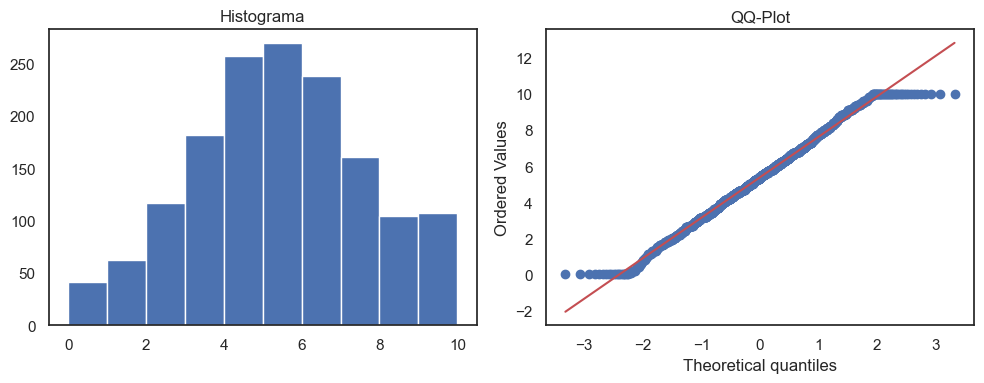

Média da amostra: 5.376
IC Bootstrap (95%): 5.266 a 5.489
p-valor Shapiro-Wilk: 0.0000 (não normal)


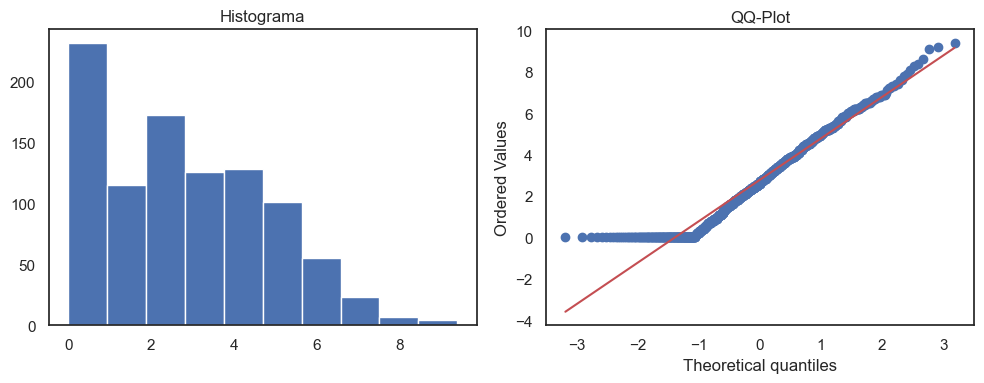

Média da amostra: 2.783
IC Bootstrap (95%): 2.657 a 2.909
p-valor Shapiro-Wilk: 0.0000 (não normal)


In [44]:
analyze_distribution_and_ci(atraso_h0)
analyze_distribution_and_ci(atraso_h1)

In [45]:
teste_mann_w_u(atraso_h0,atraso_h1,hipotese_nula_atraso)

Estatística U: 1183034.0
p-valor: 1.224521170143194e-140
Resultado: Há diferença simgnificativa.
Rejeitamos a hipótese nula (H0): NPS se mantem igual com até dois dias de atraso


##### <font size="5">h1 = a partir do segundo contato existe maior probabilidade dos clientes se tornarem detratores</font>

In [46]:
hipotese_nula_contatos = 'Não há alteração no NPS com menos de dois contatos com o SAC'
contatos_h0 = df_nps[df_nps['customer_service_contacts'] < 2]['nps_score']
contatos_h1 = df_nps[df_nps['customer_service_contacts'] >= 2]['nps_score']

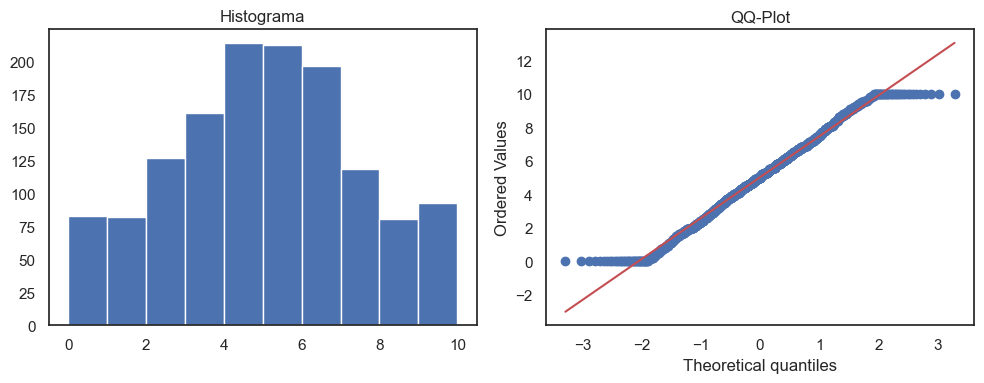

Média da amostra: 5.016
IC Bootstrap (95%): 4.886 a 5.145
p-valor Shapiro-Wilk: 0.0000 (não normal)


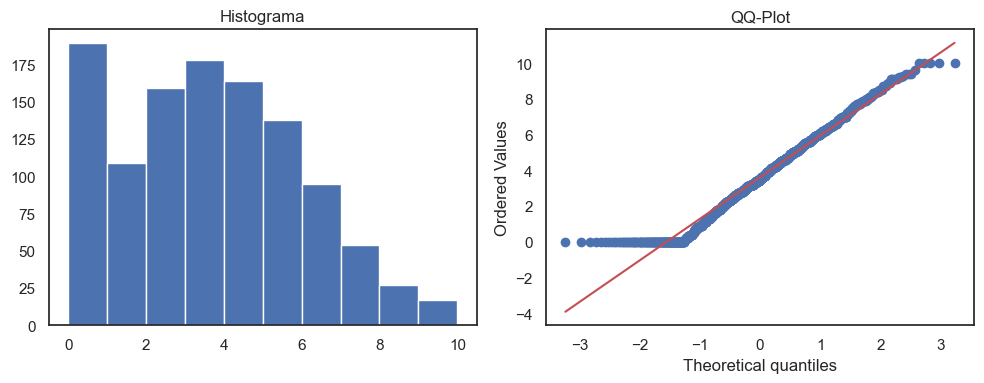

Média da amostra: 3.606
IC Bootstrap (95%): 3.472 a 3.742
p-valor Shapiro-Wilk: 0.0000 (não normal)


In [47]:
analyze_distribution_and_ci(contatos_h0)
analyze_distribution_and_ci(contatos_h1)

In [48]:
teste_mann_w_u(contatos_h0,contatos_h1,hipotese_nula_contatos)

Estatística U: 1021819.5
p-valor: 2.677195218819886e-43
Resultado: Há diferença simgnificativa.
Rejeitamos a hipótese nula (H0): Não há alteração no NPS com menos de dois contatos com o SAC


##### <font size="5">h1 = a partir do terceiro dia sem a resolução de problemas, existe uma maior probabilidade do cliente se tornar detrator </font>

In [49]:
hipotese_nula_resolucao = 'Não há alteração no NPS com menos de dois resolucao de problemas'
resolucao_h0 = df_nps[df_nps['resolution_time_days'] < 3]['nps_score']
resolucao_h1 = df_nps[df_nps['resolution_time_days'] >= 3]['nps_score']

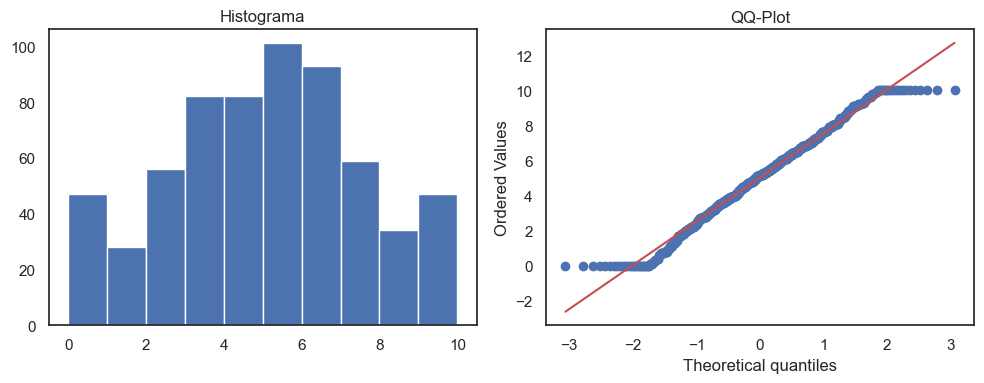

Média da amostra: 5.041
IC Bootstrap (95%): 4.847 a 5.236
p-valor Shapiro-Wilk: 0.0000 (não normal)


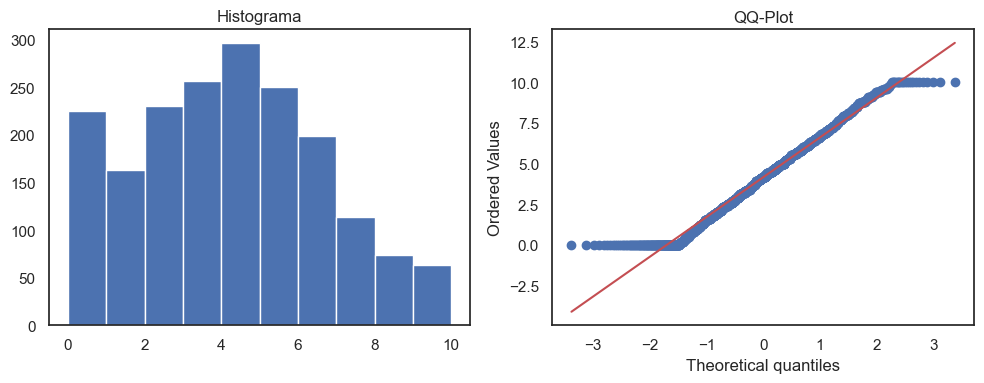

Média da amostra: 4.156
IC Bootstrap (95%): 4.043 a 4.268
p-valor Shapiro-Wilk: 0.0000 (não normal)


In [50]:
analyze_distribution_and_ci(resolucao_h0)
analyze_distribution_and_ci(resolucao_h1)

In [51]:
teste_mann_w_u(resolucao_h0,resolucao_h1,hipotese_nula_resolucao)

Estatística U: 708017.5
p-valor: 2.217160622719586e-14
Resultado: Há diferença simgnificativa.
Rejeitamos a hipótese nula (H0): Não há alteração no NPS com menos de dois resolucao de problemas


#### <font size="6"> **Conclusão das hipoteses:** </font> <br>
**Nossas hipoteses foram validadas** <br>

Para mentermos o NPS alto precisamos evitar mais de duas reclamações, não atrasar mais de um dia, resolver os problemas no primeiro contato dos clientes e em até dois dias após o contato

### Analise de perfil de cliente

primeiro vamos tentar criar um perfil com base nas hipoteses que levantamos, criando um score ponderado(Heuristica) 

OBS: Eu fiz essa analise primeiro, mas posteriormente mudei para uma analise utilizando o kmeans mantive essa técnica no código, apenas para manter registrado

In [52]:
# Definindo os pesos com base na sua correlação
df_nps['risk_score'] = (
    (df_nps['complaints_count'] >= 3).astype(int) * 2 +          # Forte corr (-0.44)
    (df_nps['delivery_delay_days'] >= 2).astype(int) * 2 +       # Forte corr (-0.41)
    (df_nps['customer_service_contacts'] >= 2).astype(int) * 1 + # Média corr (-0.24)
    (df_nps['resolution_time_days'] >= 3).astype(int) * 1        # Baixa corr (-0.15)
)

# -1 a 1: Baixo (No máximo 1 problema leve)
# 2 a 3: Médio (Problema grave ou combinação de leves)
# 4 a 5: Alto (Combo de problemas graves)
# 6 : Critico - Pontuação máxima


df_nps['risk_level'] = pd.cut(
    df_nps['risk_score'],
    bins=[-1, 1, 3, 5, 6], 
    labels=['Baixo', 'Médio', 'Alto', 'Crítico']
)

In [53]:
# relação 
print(df_nps.groupby('risk_level', observed=False)['order_value'].sum())

risk_level
Baixo      103676.83
Médio      238193.88
Alto       507889.71
Crítico    235888.93
Name: order_value, dtype: float64


In [54]:
# Verificando a média de NPS por nível de risco
print(df_nps.groupby('risk_level', observed=False)['nps_score'].mean())

risk_level
Baixo      7.534199
Médio      5.798895
Alto       3.976500
Crítico    2.491897
Name: nps_score, dtype: float64


Seguindo a sugestão do Professor Ariel decidi fazer uma nova analise, a criação do perfil de risco acima foi feita de acordo com a lógica convencional, utilizando de regras bem estabelicidas e especificas, a sugestão foi criar um algoritmo de ML para fazer o mesmo trabalho de classificação.

In [55]:
#Mantendo as mesmas colunas selecionadas anteriormente
colunas_risco = ['delivery_delay_days',
                 'customer_service_contacts',
                 'resolution_time_days',
                 'repeat_purchase_30d',
                 'complaints_count']



X = df_nps[colunas_risco]

# Padronizando os dados 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Treina o modelo K-Means (3 - clusters)
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster_risco'] = kmeans.fit_predict(X_scaled)


Analise da média das variaveis encontradas em cada um dos grupos de risco definidos pelo modelo k-means

In [56]:
cluster_map = {0:'médio',1:'baixo',2:'critico'}
df.groupby(df['cluster_risco'].map(cluster_map))[colunas_risco].mean()

,delivery_delay_days,customer_service_contacts,resolution_time_days,repeat_purchase_30d,complaints_count
cluster_risco,,,,,
baixo,0.760369,0.783410,4.129032,1.000000,2.387097
critico,2.269555,2.824308,5.685921,0.001203,6.040915
médio,2.353306,0.882920,5.573691,0.000000,3.331956


Analise de percentual das categorias de NPS em cada uma dos Clusters de risco

In [57]:
# Tabela com os percentuais dos clusters mapeado pelo nps 
pd.crosstab(df['cluster_risco'].map(cluster_map), df_nps['nps_cat'].map(nps_map), normalize='index') * 100


nps_cat,Detratores,Passivo,Promotores
cluster_risco,,,
baixo,0.000000,7.834101,92.165899
critico,91.817088,8.062575,0.120337
médio,74.931129,25.068871,0.000000


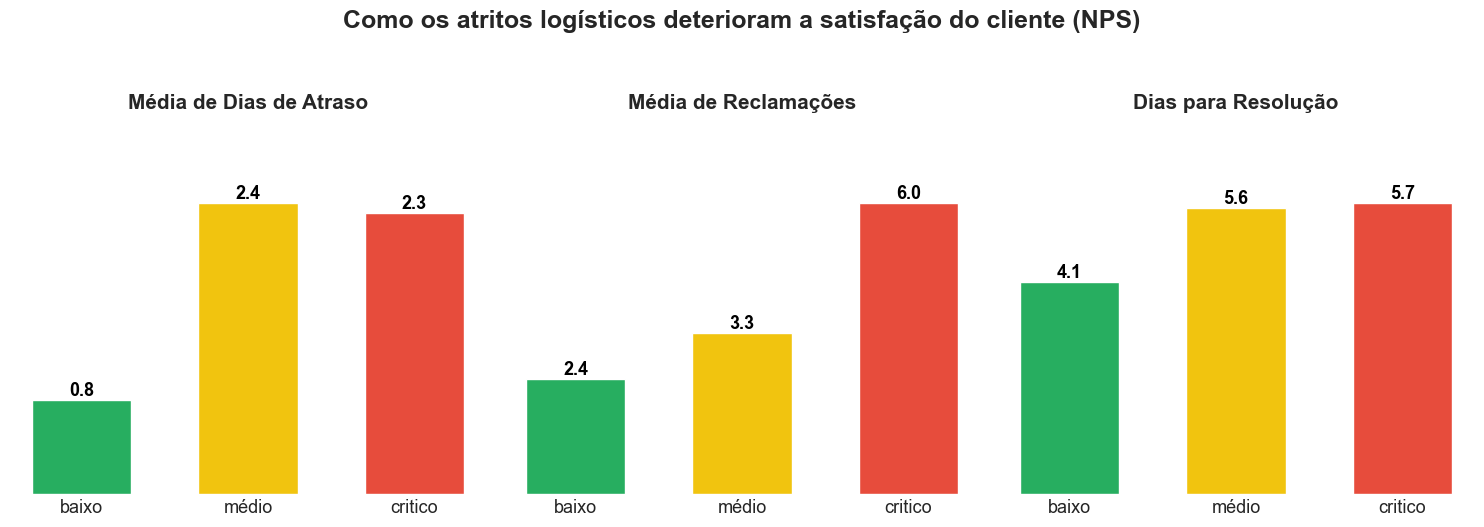

In [58]:
# Escolher as variáveis que mais "doem" no cliente para o slide
vars_chave = ['delivery_delay_days', 'complaints_count', 'resolution_time_days']
titulos_vars = ['Média de Dias de Atraso', 'Média de Reclamações', 'Dias para Resolução']

# Calcula as médias
medias_cluster = df.groupby(df['cluster_risco'].map(cluster_map))[vars_chave].mean()

# Forçar a ordem lógica para contar a história (do melhor pro pior cenário)
ordem_clusters = ['baixo', 'médio', 'critico']
medias_cluster = medias_cluster.reindex(ordem_clusters)

# Criando a figura (1 linha, 3 colunas)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_alpha(0.0) #fundo transparente

# Cores para os clusters (Baixo = Verde, Médio = Amarelo, Crítico = Vermelho)
cores = ['#27AE60', '#F1C40F', '#E74C3C']

# Criando cada um dos gráficos em um loop
for i, col in enumerate(vars_chave):
    ax = axes[i]
    ax.patch.set_alpha(0.0) 
    
    # Cria o gráfico de barras verticais
    bars = ax.bar(medias_cluster.index, medias_cluster[col], color=cores, width=0.6)
    
    # Adiciona o Título específico de cada painel
    ax.set_title(titulos_vars[i], fontsize=15, fontweight='bold', pad=15)
    
    # Colocando os rótulos de dados (números) no topo de cada barra
    for bar in bars:
        altura = bar.get_height()
        # Se for 0, deixa um traço, se não, formata com 1 casa decimal
        texto = f'{altura:.1f}' if altura > 0 else '0'
        
        ax.text(bar.get_x() + bar.get_width()/2, altura, texto, 
                va='bottom', ha='center', color='black', fontweight='bold', fontsize=13)
        
    # Limpeza visual Extrema
    sns.despine(ax=ax, left=True, bottom=True)
    ax.get_yaxis().set_visible(False)
    ax.tick_params(axis='x', length=0, labelsize=13) 
    

    ax.set_ylim(0, medias_cluster[col].max() * 1.25)

plt.suptitle('Como os atritos logísticos deterioram a satisfação do cliente (NPS)', 
             fontsize=18, fontweight='bold', y=1.05)

plt.tight_layout()


target_dir = Path("../docs/images")
target_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(target_dir / "impacto_operacional_clusters.png", transparent=True, bbox_inches='tight', dpi=300)

plt.show()


In [59]:
print(df.groupby(df['cluster_risco'].map(cluster_map), observed=False)['order_value'].sum())
#Order value encontrado anteriormente : 
# Baixo      103676.83
# Médio      238193.88
# Alto       507889.71
# Crítico    235888.93

cluster_risco
baixo       98851.07
critico    364033.49
médio      622764.79
Name: order_value, dtype: float64


**Breve conclusão:**
O professor ariel sugeriu que eu tentasse a RF ou RL para o problema, pesquisando sobre modelos de categoria por aproximação vi que o k-means poderia ser uma boa solução, ao fazer o teste encontrei valores próximos ao que havia chegado de forma manual. 

compreendendo esses perfis de risco quero criar um argumento em numero de faturamento, embora o target seja o nps o objetivo final é melhorar o faturamento da empresa, aproveitando esssas categorias do cluster farei alguns calculos para conseguir tirar o quanto o nps afeta a recompra de nossos clientes, a partir dessa visão poderei argumentar o quão positivo é para nossa empresa a satisfação do cliente

In [60]:
# feito uma coluna auxiliar, se nao houver recompra entende-se que o valor do repeat purchase é 0 entao é retornado 0 
df['valor_da_recompra'] = df['order_value'] * df['repeat_purchase_30d']

# Agrupando os valores
analise_faturamento = df.groupby(df['cluster_risco'].map(cluster_map)).agg(
    percentual_recompra=('repeat_purchase_30d', 'mean'),
    valor_total_recompra=('valor_da_recompra', 'sum')
)

percentual_da_carteira = round(df['valor_da_recompra'].sum() / df['order_value'].sum() ,2) 

print(f" representação da recompra em nosso faturamento {percentual_da_carteira * 100}%")

analise_faturamento['percentual_recompra'] *= 100
display(analise_faturamento)



 representação da recompra em nosso faturamento 9.0%


,percentual_recompra,valor_total_recompra
cluster_risco,,
baixo,100.000000,98851.07
critico,0.120337,608.02
médio,0.000000,0.00


O Nosso nps de risco baixo tem 100% de percentual de recompra, podemos observar que 9% do faturamento total da base vem do perfil de baixo risco. 
em um mês tivemos um ganho de quase 100mil reais vindo desse perfil. 
isso é um dado muito importante que precisa ser utilizado

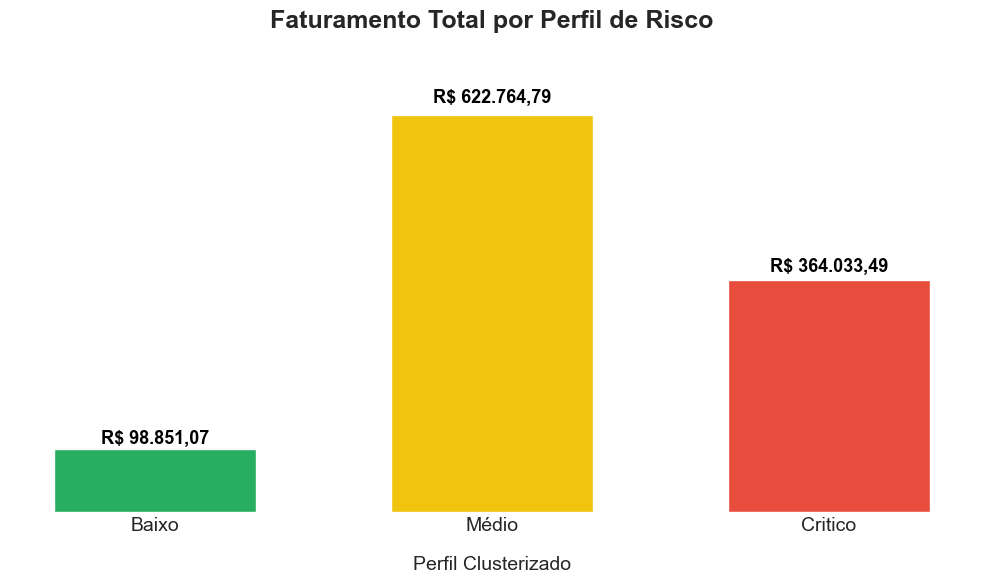

In [61]:
faturamento_total = df.groupby(df['cluster_risco'].map(cluster_map), observed=False)['order_value'].sum()
faturamento_total = faturamento_total.reindex(['baixo', 'médio', 'critico'])


sns.set_theme(style="white") 
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_alpha(0.0) 


cores = ['#27AE60', '#F1C40F', '#E74C3C']
bars = ax.bar([x.title() for x in faturamento_total.index], faturamento_total.values, color=cores, width=0.6)


for bar in bars:
    altura = bar.get_height()
    texto_moeda = f'R$ {altura:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')
    
    ax.text(bar.get_x() + bar.get_width() / 2, altura + (altura * 0.02), 
            texto_moeda, 
            ha='center', va='bottom', fontsize=13, fontweight='bold', color='black')

# 6. Textos e Limpeza Visual
ax.set_title('Faturamento Total por Perfil de Risco', fontsize=18, pad=20, fontweight='bold')
ax.set_xlabel('Perfil Clusterizado', fontsize=14, labelpad=15)

ax.set_ylabel('')
ax.get_yaxis().set_visible(False)
sns.despine(left=True, bottom=True) 
ax.tick_params(axis='x', length=0, labelsize=14) 


ax.set_ylim(0, faturamento_total.max() * 1.15)

plt.tight_layout()

target_dir = Path("../docs/images")
target_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(target_dir / "faturamento_por_cluster.png", transparent=True, bbox_inches='tight', dpi=300)

plt.show()


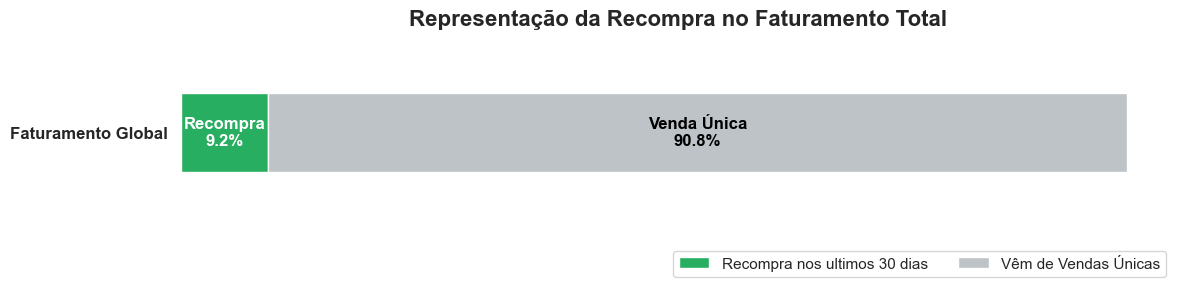

In [62]:
import pandas as pd
import matplotlib.pyplot as plt



faturamento_recompra = df['valor_da_recompra'].sum()
faturamento_venda_unica = df['order_value'].sum() - faturamento_recompra
faturamento_total = df['order_value'].sum()

# Criar um DataFrame com 1 única linha para fazer a barra empilhada
df_barh = pd.DataFrame({
    'Recompra nos ultimos 30 dias': [faturamento_recompra],
    'Vêm de Vendas Únicas': [faturamento_venda_unica]
}, index=['Faturamento Global'])

# Gerar o gráfico barh empilhado
ax = df_barh.plot(
    kind='barh', 
    stacked=True, 
    figsize=(12, 3),
    color=['#27AE60', '#BDC3C7'] # Verde para recompra, Cinza para venda única
)

# Customização plt
plt.title('Representação da Recompra no Faturamento Total', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Valor em Reais (R$)', fontsize=13)
plt.yticks(fontsize=12, fontweight='bold')
plt.legend(loc='upper right', bbox_to_anchor=(1, -0.2), ncol=2) # Joga a legenda para baixo


# Calculo de percentual
pct_recompra = (faturamento_recompra / faturamento_total) * 100
ax.text(faturamento_recompra / 2, 0, f'Recompra\n{pct_recompra:.1f}%', 
        ha='center', va='center', color='white', fontweight='bold', fontsize=12)

# Formatação numerica
pct_venda_unica = (faturamento_venda_unica / faturamento_total) * 100
ax.text(faturamento_recompra + (faturamento_venda_unica / 2), 0, f'Venda Única\n{pct_venda_unica:.1f}%', 
        ha='center', va='center', color='black', fontweight='bold', fontsize=12)


#limpeza 
sns.despine(left=True, bottom=True)
ax.get_xaxis().set_visible(False)  
plt.tight_layout()

salvar_fig(plt.gcf(), "percentual_recompra_barh.png")

plt.show()


In [63]:
#Filtrar apenas as colunas que podem trazer alguma analise para o perfil dos nossos clientes

df_perfil = df_nps[['customer_age',
                    'customer_tenure_months',
                    'order_value',
                    'items_quantity',
                    'discount_value',
                    'payment_installments',
                    'delivery_time_days',
                    'delivery_delay_days',
                    'freight_value',
                    'delivery_attempts',
                    'customer_service_contacts',
                    'resolution_time_days',
                    'repeat_purchase_30d',
                    'complaints_count',
                    'customer_region_encoded',
                    'risk_score',
                    'risk_level']
                ]

perfil = df_perfil.groupby('risk_level', observed=False).mean(numeric_only=True)

perfil.T

risk_level,Baixo,Médio,Alto,Crítico
customer_age,43.367965,43.769797,42.869822,44.180479
customer_tenure_months,60.229437,62.751381,60.630600,61.865562
order_value,448.817446,438.662762,429.323508,434.417919
items_quantity,3.320346,3.561694,3.477599,3.429098
discount_value,30.651775,32.294383,29.292781,27.797937
payment_installments,6.082251,6.103131,5.889265,6.121547
delivery_time_days,8.060606,7.804788,8.138631,7.968692
delivery_delay_days,0.510823,1.467772,2.479290,2.983425
freight_value,37.903030,37.950755,38.532857,37.928748
delivery_attempts,2.004329,2.012891,2.009298,1.990792


Faremos uma comparação de diferentes niveis de risco, utilizando o grupo de baixo risco como referencia (baseline= 1) <br>
Isso nos permitirá entender o quanto os problemas operacionais aumentam a medida que o risco do cliente cresce

In [64]:
def grafico_impacto_relativo(perfil):
    cores_temperatura = ['#49D06D', '#C7F05A', '#EFA63A', '#ED5453']

    # Normalização relativa ao risco baixo
    perfil_relativo = perfil / perfil.loc['Baixo']
    perfil_relativo = perfil_relativo.drop(columns=['customer_region_encoded'])

    fig, ax = plt.subplots(figsize=(15, 6))

    perfil_relativo.T.plot(
        kind='bar',
        color=cores_temperatura,
        ax=ax
    )

    # Linha de base
    ax.axhline(
        y=1,
        color='black',
        linestyle='--',
        linewidth=1.5,
        label='Base (Risco Baixo)'
    )

    # Títulos e labels
    ax.set_title(
        'Problemas aumentam significativamente conforme o risco do cliente',
        fontsize=14,
        fontweight='bold'
    )
    ax.set_ylabel('Fator de Aumento (x vezes)')
    ax.set_xlabel('')

    # Grid leve
    ax.grid(axis='y', linestyle='--', alpha=0.3)

    # Melhorar legenda
    ax.legend(frameon=False)

    # Rotação labels eixo X
    plt.xticks(rotation=45, ha='right')

    # Adicionar rótulos nos pontos relevantes (>1.2 por exemplo)
    for container in ax.containers:
        labels = [
            f"{v.get_height():.1f}x" if v.get_height() > 1.2 else ""
            for v in container
        ]
        ax.bar_label(container, labels=labels, padding=3, fontsize=9,rotation=90)

    # Salvar
    nome_arquivo = "impacto_relativo_problemas.png"
    salvar_fig(fig, nome_arquivo)

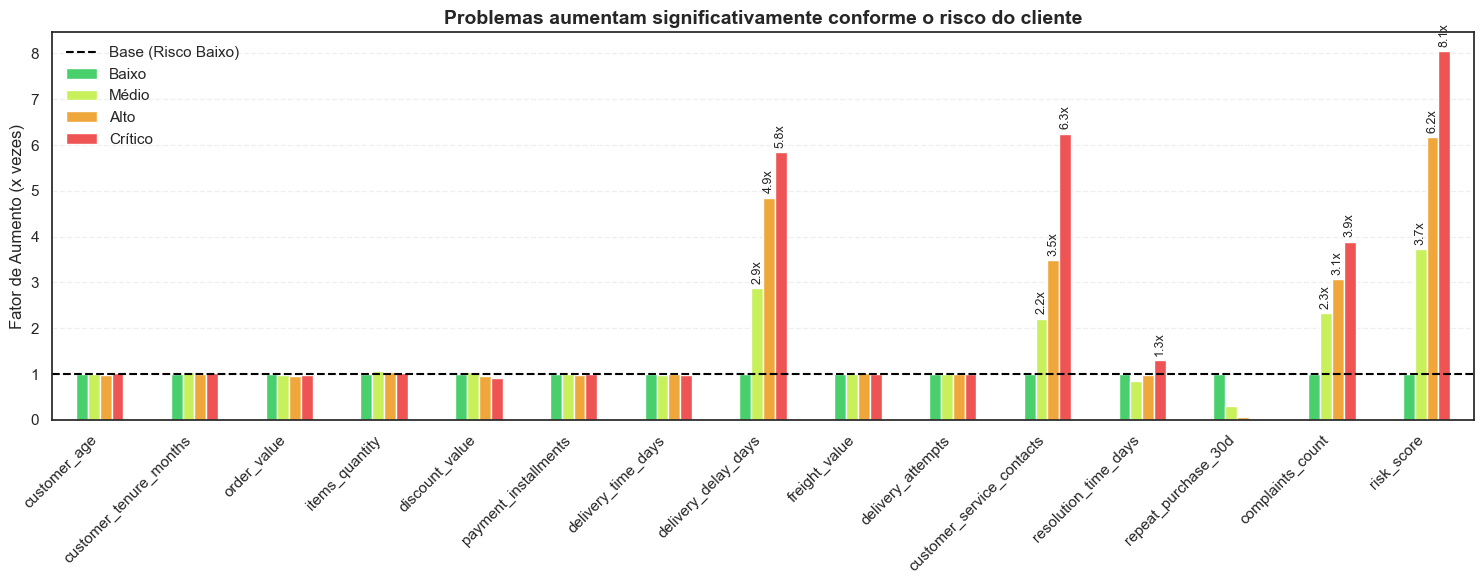

In [65]:
grafico_impacto_relativo(perfil)

Clientes de risco crítico em média, apresentam cerca de 6 vezes mais dias de atraso do que clientes de baixo risco. <br>
Clientes de risco crítico em média, apresentam cerca de 6 vezes mais contatos com o SAC do que clientes de baixo risco. <br>
Clientes de risco crítico em média, reclamam 4 vezes do que clientes de baixo risco.<br>


O tempo de entrega não é um problema, uma vez que sempre se mantem estável, entretanto o atraso na entrega demonstra um crescimento exponencial no perfil de risco de nossos clientes, um dos grandes problemas é a quebra de promessa de entrega e não o prazo médio de entrega. 

o mesmo também pode se notar ao avaliar o contato com o SAC, uma não resolução gera maior perfil de risco

#### Analise por regiao

Foi possivel identificar um pequeno destaque na região sudeste faremos uma breve analise por região para identificar se essa relação é forte

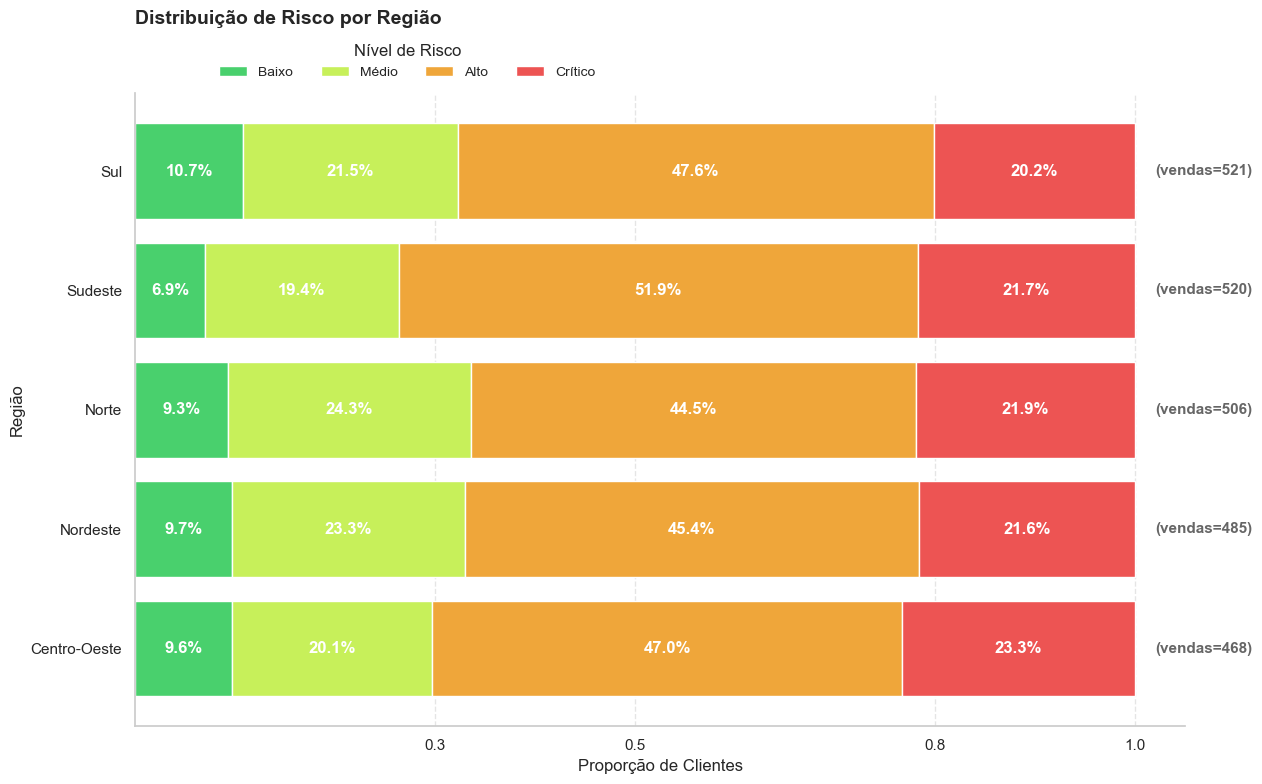

In [66]:
cores_temperatura = ['#49D06D', '#C7F05A', '#EFA63A', '#ED5453']

regioes_nomeadas = df_nps['customer_region_encoded'].map(region_mapping)
distribuicao_risco = pd.crosstab(regioes_nomeadas, df_nps['risk_level'], normalize='index')

total_por_regiao = regioes_nomeadas.value_counts().reindex(distribuicao_risco.index)

ax = distribuicao_risco.plot(
    kind='barh', 
    stacked=True, 
    figsize=(15, 8), 
    color=cores_temperatura, 
    width=0.8
)

# --- ADICIONANDO O TOTAL À DIREITA ---
for i, (regiao, total) in enumerate(total_por_regiao.items()):
    ax.text(1.02, i, f'(vendas={total})', va='center', fontsize=11, color='#666666', fontweight='bold')

plt.title('Distribuição de Risco por Região', fontsize=14, fontweight='bold', loc='left', pad=50)
plt.xlabel('Proporção de Clientes')
plt.ylabel('Região')


plt.legend(title='Nível de Risco', loc='center right', fontsize=10,
           bbox_to_anchor=(0.45, 1.05), ncol=4, frameon=False)


for p in ax.patches:
    width = p.get_width()
    if width > 0.05: 
        ax.annotate(f'{width:.1%}', 
                    (p.get_x() + width/2, p.get_y() + p.get_height()/2),
                    ha='center', va='center', color='white', fontweight='bold')

ax.set_xticks([0.3, 0.5, 0.8, 1])
ax.grid(True, axis='x', linestyle='--', alpha=0.5)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

plt.tight_layout(rect=[0, 0, 0.85, 1])  
plt.show()

>as regiões estão relativamente próximas em distribuição de vendas
é possivel verificar que a região sul possui acumulo de perfil de baixo risco, talvez identificado por um menor atraso na região.<br>
também é possivel notar um maior nivel de risco na região sudeste <br>
Mas não foi visto o perfil de região como algo substancial para o nosso perfil de risco <br>
de qualquer forma, acho que podemos posteriormente estudar se existe essa relação

### validação de perfis

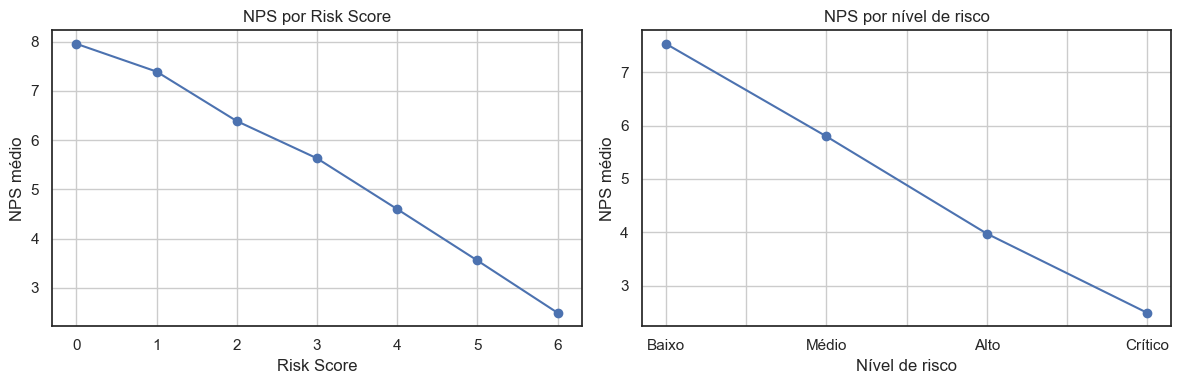

In [67]:
# esse gráfico perdeu o sentido quando mudei o método de analise para o kmeans, mas mantive no código para registro pessoal 

fig, axes = plt.subplots(1, 2, figsize=(12,4))

# Gráfico 1 - contínuo
df_nps.groupby('risk_score',observed=False)['nps_score'].mean().plot(
    marker='o', ax=axes[0]
)
axes[0].set_title('NPS por Risk Score')
axes[0].set_xlabel('Risk Score')
axes[0].set_ylabel('NPS médio')
axes[0].grid()

# Gráfico 2 - categórico
df_nps.groupby('risk_level',observed=False)['nps_score'].mean().plot(
    marker='o', 
    ax=axes[1]
)
axes[1].set_title('NPS por nível de risco')
axes[1].set_xlabel('Nível de risco')
axes[1].set_ylabel('NPS médio')
axes[1].grid()

plt.tight_layout()
plt.show()

Identificação de relação direta do risk_score com o nps_score, categoricamente e quantitativamente

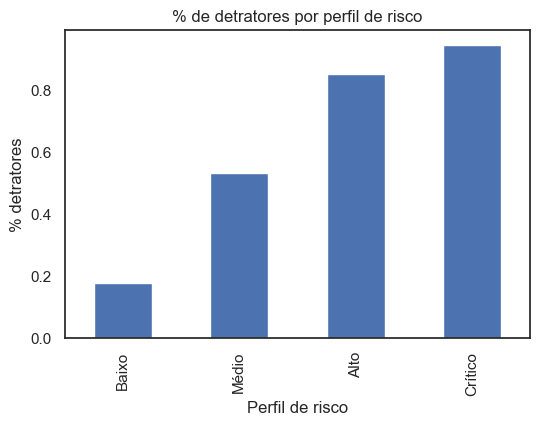

In [68]:
# esse gráfico perdeu o sentido quando mudei o método de analise para o kmeans, mas mantive no código para registro pessoal 

df_nps['is_detrator'] = (df_nps['nps_cat'] == 1)

plt.figure(figsize=(6,4))
df_nps.groupby('risk_level',observed=False)['is_detrator'].mean().plot(kind='bar')
plt.title('% de detratores por perfil de risco')
plt.ylabel('% detratores')
plt.xlabel('Perfil de risco')
plt.show()

é possivel visualizar um acumulo de percentual de detratores, conforme o risco se eleva 

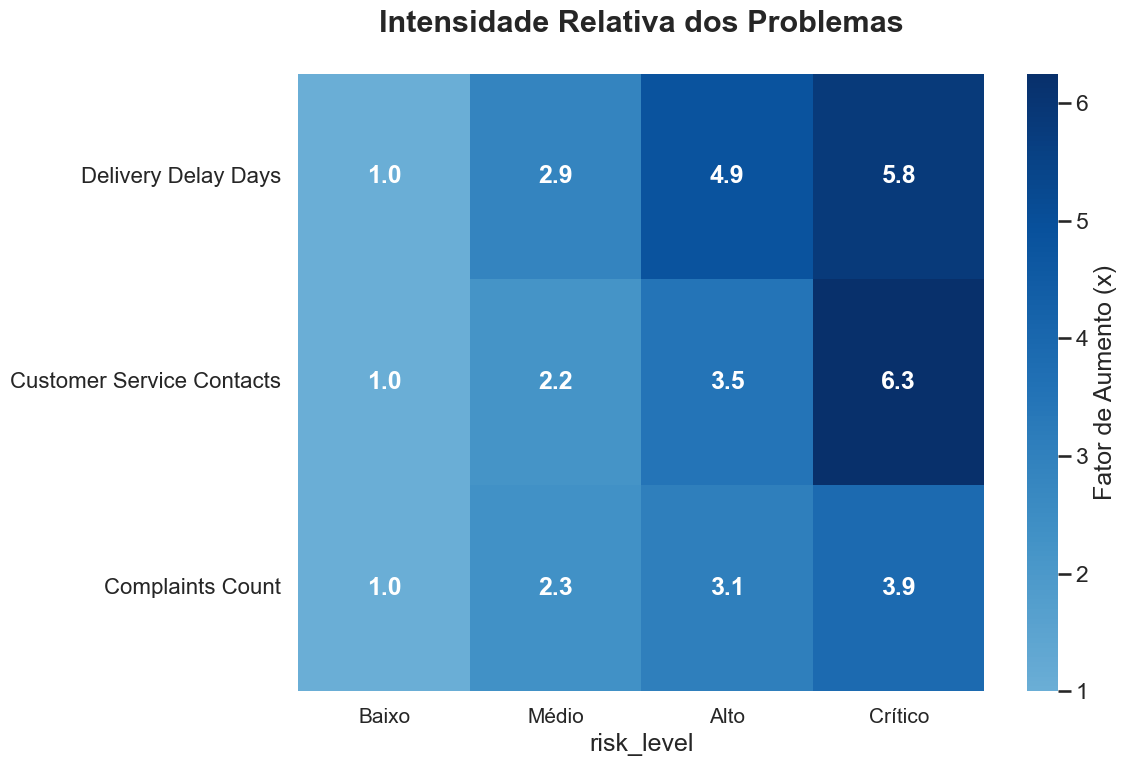

In [69]:
# esse gráfico perdeu o sentido quando mudei o método de analise para o kmeans, mas mantive no código para registro pessoal 

perfil_relativo = perfil / perfil.loc['Baixo']

cols = ['delivery_delay_days', 'customer_service_contacts', 'complaints_count']
sns.set_context("talk") 
fig, ax = plt.subplots(figsize=(12, 8))

# ------ HEATMAP 
sns.heatmap(perfil_relativo[cols].T, 
            annot=True, 
            fmt=".1f", 
            cmap='Blues', 
            center=1, 
            ax=ax, 
            annot_kws={"size": 18, "weight": "bold"}, 
            cbar_kws={'label': 'Fator de Aumento (x)'})

ax.set_title('Intensidade Relativa dos Problemas', fontsize=22, pad=30, fontweight='bold')

labels_limpos = [c.replace('_', ' ').title() for c in cols]

ax.set_yticks([x + 0.5 for x in range(len(labels_limpos))]) # Centraliza o texto na célula
ax.set_yticklabels(labels_limpos, fontsize=16, rotation=0)
ax.tick_params(axis='x', labelsize=15)
ax.set_ylabel('', fontsize=0)


plt.tight_layout()



target_dir = Path("../docs/images")
target_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(target_dir / "heatmap_intensidade_problemas.png", bbox_inches='tight', dpi=300)

plt.show()

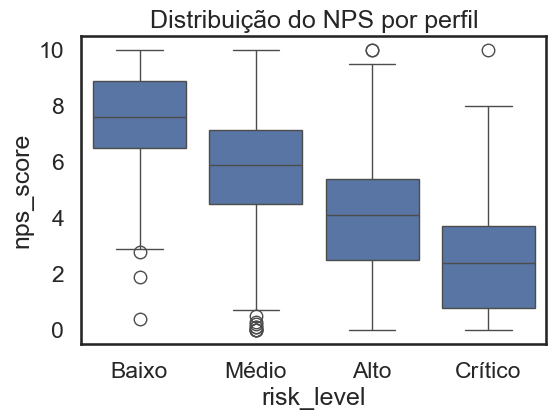

In [70]:
# esse gráfico perdeu o sentido quando mudei o método de analise para o kmeans, mas mantive no código para registro pessoal  

plt.figure(figsize=(6,4))
sns.boxplot(x='risk_level', y='nps_score', data=df_nps)
plt.title('Distribuição do NPS por perfil')
plt.show()

Por fim uma visualização da proporção dos problemas x nivel de risco em uma escala maior 

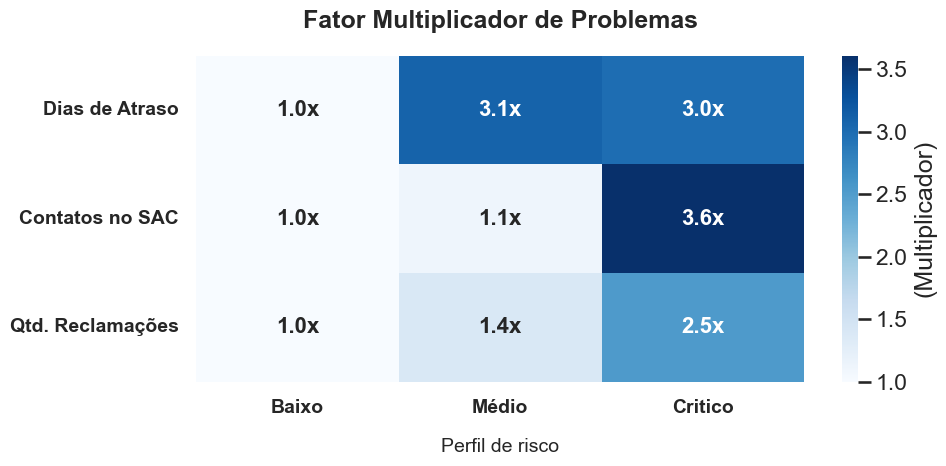

In [71]:
cols = ['delivery_delay_days', 'customer_service_contacts', 'complaints_count']

perfil = df.groupby(df['cluster_risco'].map(cluster_map))[cols].mean()
perfil = perfil.reindex(['baixo', 'médio', 'critico'])
perfil_relativo = perfil / perfil.loc['baixo']

sns.set_context("talk") 
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_alpha(0.0)

# ------ HEATMAP RELATIVO
matriz_anotacao = perfil_relativo[cols].T.map(lambda v: f"{v:.1f}x")

sns.heatmap(perfil_relativo[cols].T, 
            annot=matriz_anotacao, 
            fmt="",   
            cmap='Blues', 
            ax=ax, 
            annot_kws={"size": 16, "weight": "bold"}, 
            cbar_kws={'label': '(Multiplicador)'})

ax.set_title('Fator Multiplicador de Problemas', fontsize=18, pad=20, fontweight='bold')

labels_limpos = ['Dias de Atraso', 'Contatos no SAC', 'Qtd. Reclamações']
ax.set_yticks([x + 0.5 for x in range(len(labels_limpos))]) 
ax.set_yticklabels(labels_limpos, fontsize=14, rotation=0, fontweight='bold')
ax.set_xticklabels([x.title() for x in perfil.index], fontsize=14, fontweight='bold')
ax.set_xlabel('Perfil de risco', fontsize=14, labelpad=15)
ax.set_ylabel('', fontsize=0)

plt.tight_layout()

target_dir = Path("../docs/images")
target_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(target_dir / "heatmap_intensidade_relativa.png", transparent=True, bbox_inches='tight', dpi=300)

plt.show()


In [72]:
# feito uma coluna auxiliar, se nao houver recompra entende-se que o valor do repeat purchase é 0 entao é retornado 0 
df['valor_da_recompra'] = df['order_value'] * df['repeat_purchase_30d']

# Agrupando os valores
analise_faturamento = df.groupby(df['cluster_risco'].map(cluster_map)).agg(
    percentual_recompra=('repeat_purchase_30d', 'mean'),
    valor_total_recompra=('valor_da_recompra', 'sum')
)

percentual_da_carteira = round(df['valor_da_recompra'].sum() / df['order_value'].sum() ,2) 

print(f" representação da recompra em nosso faturamento {percentual_da_carteira * 100}%")

analise_faturamento['percentual_recompra'] *= 100
display(analise_faturamento)



 representação da recompra em nosso faturamento 9.0%


,percentual_recompra,valor_total_recompra
cluster_risco,,
baixo,100.000000,98851.07
critico,0.120337,608.02
médio,0.000000,0.00


Analise da distribuição de NPS por perfil. <br>
perfil de baixo risco tende a ter um NPS próximo a 8 <br>
médio próximo a 6<br>
Alto próximo a 4 <br>
e critico próximo a 2

# 4. Como forma de preparação para as próximas fases do curso, este desafio propõe uma reflexão prática sobre como a Ciência de Dados pode ser utilizada para antecipar a satisfação do cliente.

Vamos agora normalizar os dados para fazer alguns testes de modelos 

In [73]:
def plot_model_results(model, X_test, y_test, model_name="Modelo"):
    import matplotlib.pyplot as plt
    
    # Previsões
    y_pred = model.predict(X_test)
    
    # Criar figura
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))

    # --- Gráfico 1: Real vs Previsto ---
    ax[0].scatter(y_test, y_pred, alpha=0.5)
    ax[0].plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--', lw=2
    )
    ax[0].set_xlabel('Valores Reais')
    ax[0].set_ylabel('Previsões')
    ax[0].set_title(f'Real vs Previsto ({model_name})')

    # --- Gráfico 2: Resíduos ---
    residuos = y_test - y_pred
    ax[1].hist(residuos, bins=30, edgecolor='black')
    ax[1].axvline(0, linestyle='--')
    ax[1].set_xlabel('Erro (Resíduo)')
    ax[1].set_ylabel('Frequência')
    ax[1].set_title(f'Distribuição dos Erros ({model_name})')

    plt.tight_layout()
    #return plt
    plt.show()
    
 
    

def avaliar(nome, y_true, y_pred):
    print(f"\n=== {nome} ===")
    print(f"MAE:  {mean_absolute_error(y_true, y_pred):.3f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.3f}")
    print(f"R²:   {r2_score(y_true, y_pred):.3f}")

In [74]:
df_nps.head(2).T

,0,1
customer_age,63,20
customer_tenure_months,14,1
order_id,50001,50002
order_value,139.73,458.95
items_quantity,4,2
discount_value,39.35,9.51
payment_installments,4,10
delivery_time_days,2,6
delivery_delay_days,2,4
freight_value,55.53,28.23


Vamos começar com o one-hot encoder para separarmos as regiões, para isso vamos recuperar as colunas categorias 

In [75]:

#Recriamos o nome da região utilizando nosso map
df_nps['region_name'] = df_nps['customer_region_encoded'].map(region_mapping)

#Configuramos o Encoder e enviamos a coluna de região para ser transformada em One-Hot
cat_encoder = OneHotEncoder()
region_1hot = cat_encoder.fit_transform(df_nps[['region_name']])

# 3. Criamos o DataFrame com os nomes automáticos (que agora serão os nomes das regiões)
df_1hot = pd.DataFrame(
    region_1hot.toarray(), 
    columns=cat_encoder.get_feature_names_out(['region_name']),
    index=df_nps.index
)

# 4. Concatenamos e removemos a coluna temporária  
df_nps = pd.concat([df_nps, df_1hot], axis=1).drop(['region_name'], axis=1)

In [76]:
features = [
    'complaints_count',
    'delivery_delay_days',
    'customer_service_contacts',
    'resolution_time_days',
    'delivery_time_days',
    'delivery_attempts',
    'order_value',
    'items_quantity',
    'discount_value',
    'payment_installments',
    'freight_value',
    'customer_age',
    'customer_tenure_months',
    'repeat_purchase_30d',
    'region_name_Centro-Oeste',
    'region_name_Nordeste',
    'region_name_Norte',
    'region_name_Sudeste',
    'region_name_Sul',
    'nps_score'  #UTILIZADO APENAS PARA TESTAR OS OUTLIERS, POIS É A VARIÁVEL TARGET
]


#Filtrar outliers
df_treino = df_nps[features].copy()
#df_treino = df_treino.query("nps_score != 0 and nps_score != 10")

y = df_treino['nps_score']
X = df_treino.drop(columns=['nps_score'])

In [77]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,   # 20% teste
    random_state=42  # reprodutibilidade
)

In [78]:
# média do treino
media_treino = y_train.mean()
# cria um vetor do mesmo tamanho do y_test
y_baseline = np.full(len(y_test), media_treino)

In [79]:
print(df_treino.shape)
print(X_train.shape)
print(y_train.shape)

(2500, 20)
(2000, 19)
(2000,)


A utlização do GridSearch serve para verificar os melhores parametros para usarmos em nossos modelos

In [80]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

#iniciamos a base da random forest
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

#criamos o grid de hiperparâmetros para testar
param_grid = {
    'max_depth': [5, 10, 15],
    'n_estimators': [100, 200],
}

grid = GridSearchCV(rf_base, param_grid, cv=3, scoring='r2')
grid.fit(X_train, y_train)

#encontramos o melhor modelo
rf = grid.best_estimator_
#Executamos o modelo
y_pred_rf = rf.predict(X_test)



In [81]:
# LinearRegression
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [82]:
# GradientBoostingRegressor


gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

In [83]:
#XGBRegressor 


xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

Avanliamos as métricas:

In [84]:


y_train_pred = lr.predict(X_train)
avaliar("Baseline", y_test, y_baseline)
avaliar("Linear Regression - treino", y_train, y_train_pred)
avaliar("Linear Regression Teste", y_test, y_pred_lr)
avaliar("Random Forest", y_test, y_pred_rf)
avaliar("Gradient Boosting", y_test, y_pred_gb)
avaliar("XGBoost", y_test, y_pred_xgb)


=== Baseline ===
MAE:  2.069
RMSE: 2.514
R²:   -0.000

=== Linear Regression - treino ===
MAE:  1.188
RMSE: 1.490
R²:   0.647

=== Linear Regression Teste ===
MAE:  1.193
RMSE: 1.497
R²:   0.645

=== Random Forest ===
MAE:  1.230
RMSE: 1.528
R²:   0.631

=== Gradient Boosting ===
MAE:  1.207
RMSE: 1.503
R²:   0.643

=== XGBoost ===
MAE:  1.206
RMSE: 1.527
R²:   0.631


Os dados indicam que o melhor modelo que temos é a regressão Linear, com o maior R² o menor MAE e RMSE

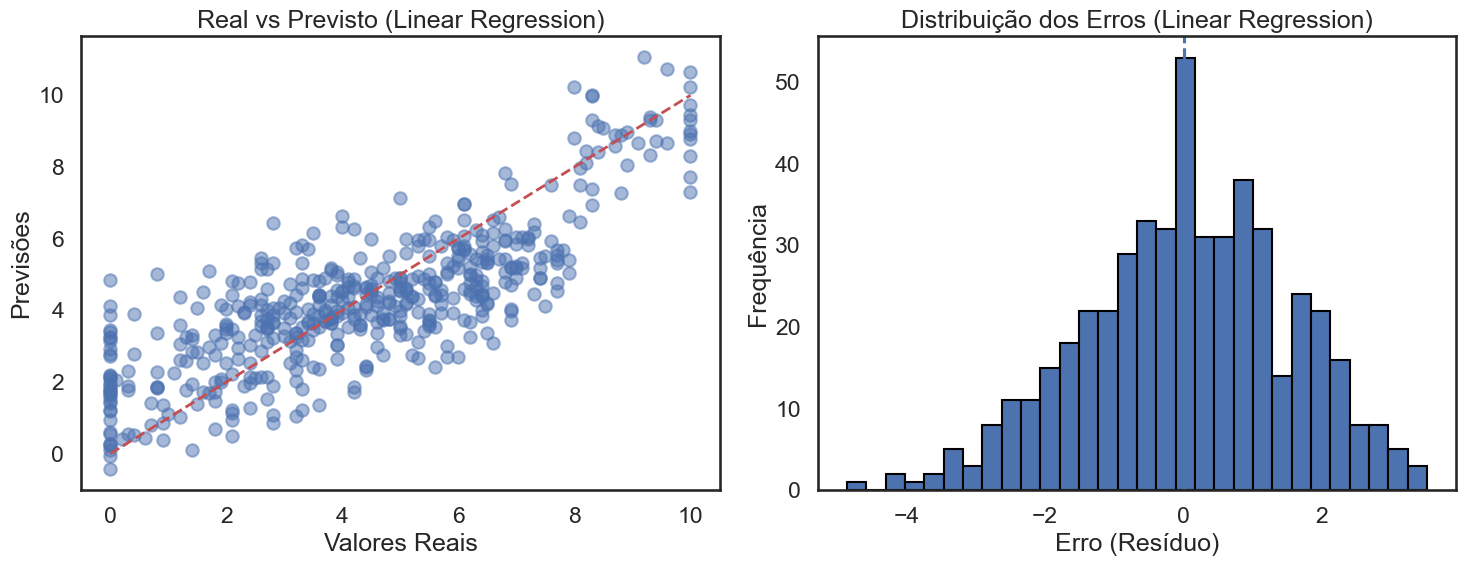

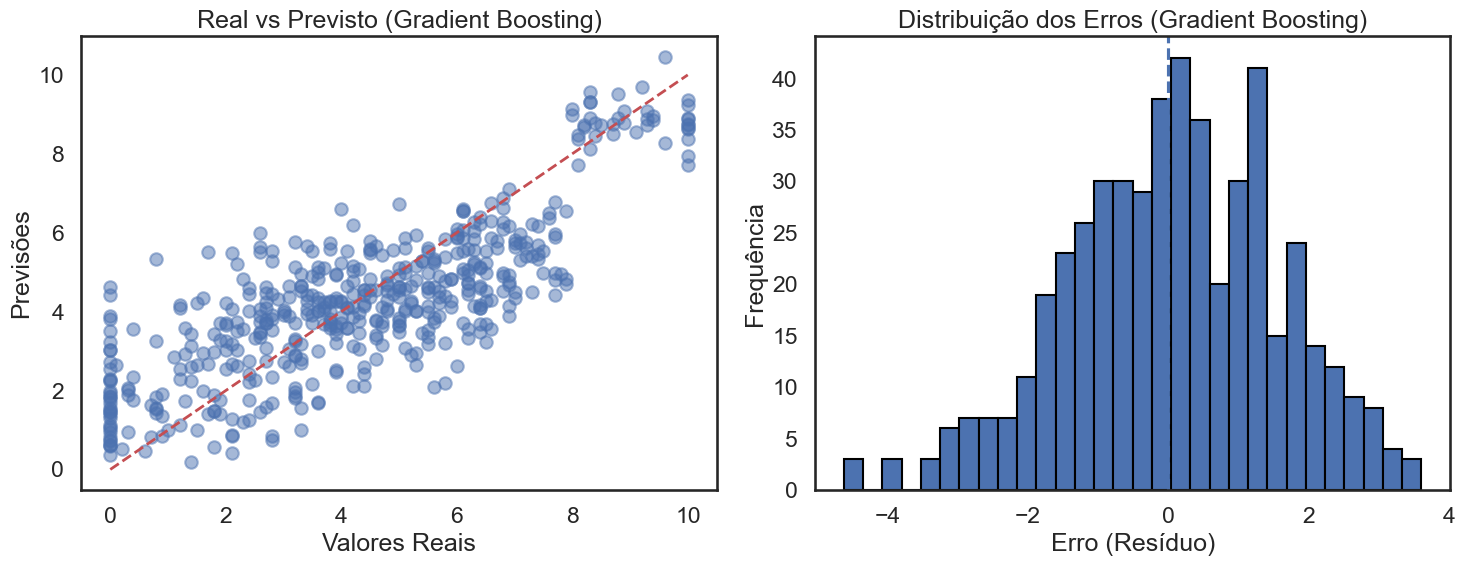

In [85]:
plot_model_results(lr, X_test, y_test, "Linear Regression")
# plot_model_results(rf, X_test, y_test, "Random Forest")
plot_model_results(gb, X_test, y_test, "Gradient Boosting")
# plot_model_results(xgb, X_test, y_test, "XGBoost")

In [86]:
#Ver o que o modelo Random Forrest aprendeu

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

print("Top 4 variáveis mais importantes:")
print(importances.head(4))

Top 4 variáveis mais importantes:
repeat_purchase_30d          0.376635
delivery_delay_days          0.214421
complaints_count             0.116440
customer_service_contacts    0.052659
dtype: float64


In [87]:
coef = pd.Series(lr.coef_, index=X.columns).sort_values()
print(coef[:3])

delivery_delay_days         -0.799046
customer_service_contacts   -0.337383
complaints_count            -0.270726
dtype: float64


In [88]:
def simular_impacto_recurso(modelo, dados_cliente, coluna, max_reducao=3):
    """
    Simula o impacto de reduzir o valor de uma coluna na previsão do modelo.
    """
    resultados = []
    print(f"\n>>> Analisando: {coluna}")
    
    for valor_reduzir in range(max_reducao + 1):
        cliente_simulado = dados_cliente.copy()
        
        # Garante que o valor não fique negativo (ex: não existe -1 reclamação)
        novo_valor = cliente_simulado[coluna] - valor_reduzir
        cliente_simulado[coluna] = max(0, novo_valor)
        
        df_input = pd.DataFrame([cliente_simulado])
        predicao = modelo.predict(df_input)[0]
        
        resultados.append(predicao)
        print(f"Redução de {valor_reduzir} unidade(s): {predicao:.2f}")
    
    return resultados

# Executando para os três cenários
res_atraso = simular_impacto_recurso(lr, X_test.iloc[6], 'delivery_delay_days')
res_contatos = simular_impacto_recurso(lr, X_test.iloc[6], 'customer_service_contacts')
res_reclamacoes = simular_impacto_recurso(lr, X_test.iloc[6], 'complaints_count')


>>> Analisando: delivery_delay_days
Redução de 0 unidade(s): 0.11
Redução de 1 unidade(s): 0.91
Redução de 2 unidade(s): 1.71
Redução de 3 unidade(s): 2.51

>>> Analisando: customer_service_contacts
Redução de 0 unidade(s): 0.11
Redução de 1 unidade(s): 0.45
Redução de 2 unidade(s): 0.79
Redução de 3 unidade(s): 1.13

>>> Analisando: complaints_count
Redução de 0 unidade(s): 0.11
Redução de 1 unidade(s): 0.38
Redução de 2 unidade(s): 0.65
Redução de 3 unidade(s): 0.93


Agora feita uma analise de melhora de nps de nossas três variaveis que mais causam detratores, vamos fazer algumas simulações para visualizar as possibilidades de melhorias se resolvessemos esses problemas com maior agilidade

In [89]:
def simular_impacto_media(modelo, dataframe_teste, coluna, n_clientes=10, max_reducao=3):
    """
    Simula o impacto médio da redução de uma variável para os N primeiros clientes.
    """
    # Seleciona os N primeiros clientes do dataframe fornecido
    clientes_selecionados = dataframe_teste.head(n_clientes)
    
    # Lista para armazenar a média das predições para cada nível de redução
    medias_nps = []
    reducoes = list(range(max_reducao + 1))
    
    for valor_reduzir in reducoes:
        predicoes_na_reducao = []
        
        # Para cada redução, rodamos o modelo para todos os clientes selecionados
        for i in range(len(clientes_selecionados)):
            cliente_simulado = clientes_selecionados.iloc[i].copy()
            
            novo_valor = cliente_simulado[coluna] - valor_reduzir
            cliente_simulado[coluna] = max(0, novo_valor)
            
            df_input = pd.DataFrame([cliente_simulado])
            predicao = modelo.predict(df_input)[0]
            predicoes_na_reducao.append(predicao)
        
        # Calcula a média do NPS previsto para todos os clientes neste nível de redução
        medias_nps.append(np.mean(predicoes_na_reducao))
    
    return reducoes, medias_nps


<Figure size 1000x500 with 0 Axes>

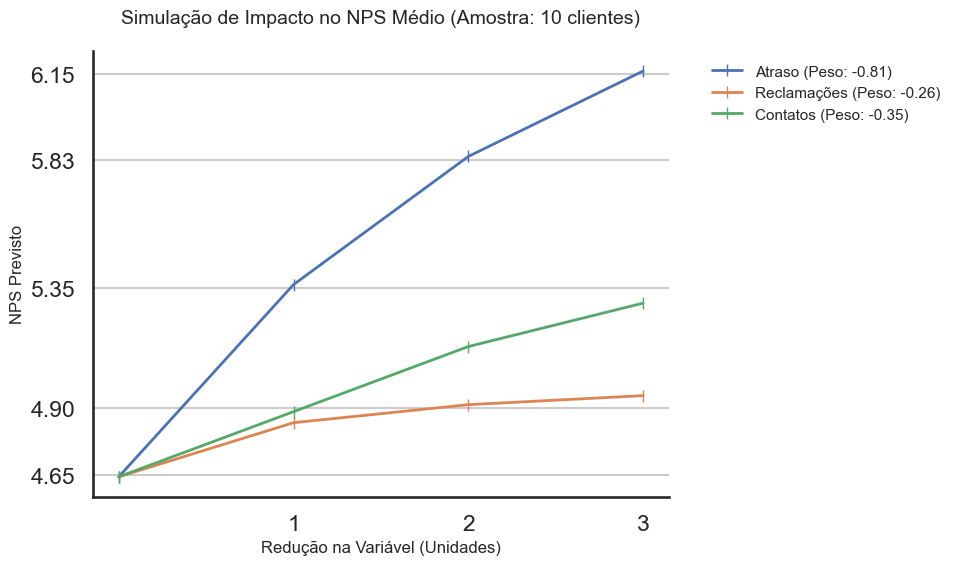

In [90]:


plt.figure(figsize=(10,5))

n_clientes_analise = 10

r, res_atraso = simular_impacto_media(lr, X_test, 'delivery_delay_days', n_clientes=n_clientes_analise)
r, res_reclamacoes = simular_impacto_media(lr, X_test, 'customer_service_contacts', n_clientes=n_clientes_analise)
r, res_contatos = simular_impacto_media(lr, X_test, 'complaints_count', n_clientes=n_clientes_analise)

# Configuração da figura
plt.figure(figsize=(10, 6))

# Plotagem das séries
plt.plot(r, res_atraso, marker='|', linewidth=2, label='Atraso (Peso: -0.81)')
plt.plot(r, res_reclamacoes, marker='|', linewidth=2, label='Reclamações (Peso: -0.26)')
plt.plot(r, res_contatos, marker='|', linewidth=2, label='Contatos (Peso: -0.35)')

# 1. Títulos e Eixos
plt.title("Simulação de Impacto no NPS Médio (Amostra: 10 clientes)", fontsize=14, pad=20)
plt.xlabel("Redução na Variável (Unidades)", fontsize=12)
plt.ylabel("NPS Previsto", fontsize=12)

plt.grid(True, axis='y')


ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xticks([1, 2, 3])
plt.yticks([4.65,4.9,5.83,5.35,  6.15])


# 5. Colocar a legenda fora do gráfico (lado direito)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False, fontsize=11)

# 6. Ajustar o layout para não cortar a legenda
plt.tight_layout()

plt.show()

In [91]:
def simular_impacto_global(modelo, X, coluna, reducao):
    X_simulado = X.copy()
    
    # aplica redução (sem deixar negativo)
    X_simulado[coluna] = (X_simulado[coluna] - reducao).clip(lower=0)
    
    # previsões
    y_pred_original = modelo.predict(X)
    y_pred_simulado = modelo.predict(X_simulado)
    
    # impacto médio
    impacto_medio = (y_pred_simulado - y_pred_original).mean()

    return impacto_medio



def gerar_grafico_impacto(coluna,modelo,qtd_analisada=4):
    
    map_categorias = {
    'delivery_delay_days':' Atraso de Entrega' ,  
    'complaints_count':' Número de Reclamações',
    'customer_service_contacts':' Número de Contatos com SAC'
    }


    impactos = []
    x = 9

    for r in range(x):
        impacto = simular_impacto_global(modelo, X_test, coluna, r)
        impactos.append(impacto)
           
    dias = ['1 Dia', '2 Dias', '3 Dias','4 Dias', '5 Dias', '6 Dias', '7 Dias', '8 Dias', '9 Dias']
    dias = dias[:qtd_analisada]
    nps_previsto = impactos[0:qtd_analisada]  
    
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 6))

    ax = sns.barplot(x=dias, y=nps_previsto, palette='viridis', hue=dias, legend=False)

    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points',
                    fontsize=12, fontweight='bold', color='#333333')


    plt.title(f"impacto da redução {map_categorias[coluna]} no NPS Previsto", fontsize=16, pad=20, fontweight='bold')
    plt.xlabel(f"{map_categorias[coluna]}", fontsize=12)
    plt.ylabel("Aumento Médio na Nota", fontsize=12)
    plt.ylim(0, 3)

    sns.despine(left=True, bottom=False)
    #plt.savefig(f"{map_categorias[coluna]}.png", bbox_inches='tight', dpi=300)

    plt.show()

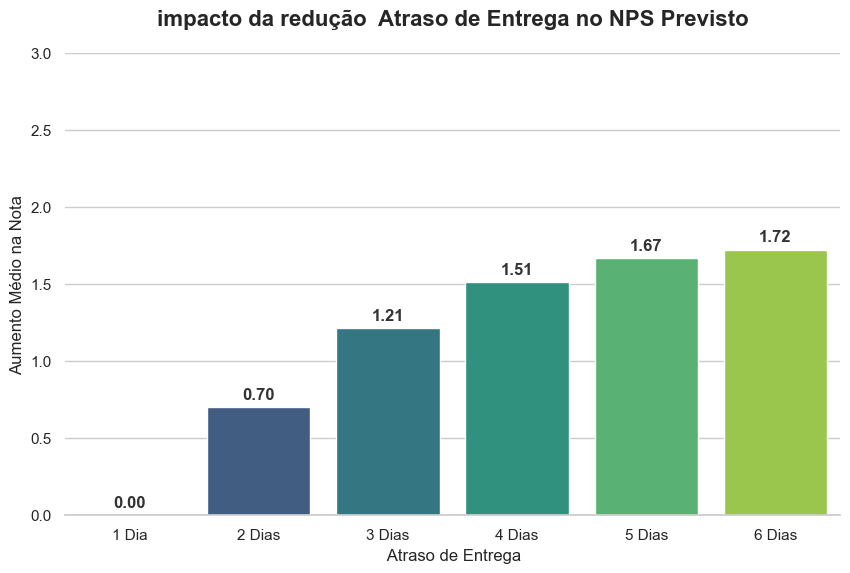

In [92]:
#gerar_grafico_impacto('complaints_count', lr, qtd_analisada=6)
gerar_grafico_impacto('delivery_delay_days', lr, qtd_analisada=6)
#gerar_grafico_impacto('delivery_delay_days', gb, qtd_analisada=6)
# gerar_grafico_impacto('customer_service_contacts', lr, qtd_analisada=4),

Façamos agora os gráficos e analises para a apresentação para diretoria 

In [93]:
def calcular_nps_da_base(notas_previstas):
    # No fim optei por nao usar nenhum round, pois ao testar notei que gerava uma variação estranha no modelo
    #notas = np.round(notas_previstas)
    #notas = np.ceil(notas_previstas)  
    notas = notas_previstas
      
    promotores = (notas >= 9).sum()
    passivos = ((notas >= 7) & (notas <= 8)).sum()
    detratores = (notas <= 6).sum()
    
    total = len(notas)
    
    pct_promotores = (promotores / total) * 100
    pct_detratores = (detratores / total) * 100
    
    nps_score = pct_promotores - pct_detratores
    
    return nps_score, pct_promotores, pct_detratores, (passivos/total)*100

# 2. Função de simulação focada na Métrica de Negócio (Categorias)
def simular_nps_categorias(modelo, X, coluna, reducao):
    X_simulado = X.copy()
    
    # Aplica a redução com limite de zero
    X_simulado[coluna] = (X_simulado[coluna] - reducao).clip(lower=0)
    
    # Previsões
    y_pred_original = modelo.predict(X)
    y_pred_simulado = modelo.predict(X_simulado)
    
    # Calcula o NPS antes e depois
    nps_orig, prom_orig, det_orig, _ = calcular_nps_da_base(y_pred_original)
    nps_sim, prom_sim, det_sim, _ = calcular_nps_da_base(y_pred_simulado)
    
    ganho_nps = nps_sim - nps_orig
    
    return {
        'reducao_aplicada': reducao,
        'nps_original': nps_orig,
        'nps_simulado': nps_sim,
        'ganho_pontos_nps': ganho_nps,
        'promotores_antes': prom_orig,
        'promotores_depois': prom_sim,
        'detratores_antes': det_orig,
        'detratores_depois': det_sim
    }

#Função para simular resultados com mais de uma categoria 
def simular_nps_cenario_combinado(modelo, X, alteracoes):
    X_simulado = X.copy()
    
    # Aplica TODAS as reduções de uma vez antes de prever
    for coluna, reducao in alteracoes.items():
        X_simulado[coluna] = (X_simulado[coluna] - reducao).clip(lower=0)
    
    # Previsões
    y_pred_original = modelo.predict(X)
    y_pred_simulado = modelo.predict(X_simulado) # Prevemos com todas as melhorias juntas
    
    # Calcula o NPS antes e depois
    nps_orig, prom_orig, det_orig, _ = calcular_nps_da_base(y_pred_original)
    nps_sim, prom_sim, det_sim, _ = calcular_nps_da_base(y_pred_simulado)
    
    ganho_nps = nps_sim - nps_orig
    
    return {
        'nps_original': nps_orig,
        'nps_simulado': nps_sim,
        'ganho_pontos_nps': ganho_nps,
        'promotores_antes': prom_orig,
        'promotores_depois': prom_sim,
        'detratores_antes': det_orig,
        'detratores_depois': det_sim
    }

In [94]:
#Função para gerar um gráfico empilhado com as três categorias 

def gerar_grafico_empilhado(modelo, dados_teste, qtd_analisada=4):
    bar_colors =['#0077b6', '#00b4d8', '#90e0ef']
    font_colors = ['#f8f9fa', '#000', '#000']

    #Descobrir qual é o NPS Atual, a variavel é delivery_delay mas como o denominador é 0 iremos entender como é a base sem nenhuma perspectiva de melhora
    nps_base = simular_impacto_global(modelo, dados_teste, 'delivery_delay_days', 0)
    
    cenarios = []
    ganhos_atraso = []
    ganhos_reclamacoes = []
    ganhos_contatos = []
    
    #Calcular o "Ganho" (Delta) para cada unidade de redução
    for r in range(1, qtd_analisada + 1):
        cenarios.append(f"Redução de {r} unid.") #Utilizo Unid. mas nao tenho certeza se é a melhor nomenclatura, mas como lidamos com dias e numeros de reclamação, achei que seria a melhor opção
        
        # Pega a simulação atual e subtrai o NPS Base
        nps_a = simular_impacto_global(modelo, dados_teste, 'delivery_delay_days', r)
        nps_r = simular_impacto_global(modelo, dados_teste, 'complaints_count', r)
        nps_c = simular_impacto_global(modelo, dados_teste, 'customer_service_contacts', r)
        
        ganhos_atraso.append(nps_a - nps_base)
        ganhos_reclamacoes.append(nps_r - nps_base)
        ganhos_contatos.append(nps_c - nps_base)

    #Criamos um DataFrame com os ganhos 
    df_plot = pd.DataFrame({
        'Atraso de Entrega': ganhos_atraso,
        'Número de Reclamações': ganhos_reclamacoes,
        'Contatos com SAC': ganhos_contatos,
    }, index=cenarios)

 
    plt.figure(figsize=(10, 6))
    
    ax = df_plot.plot(kind='barh', 
                    stacked=True, 
                    figsize=(10, 6), 
                    color=bar_colors   , 
                    edgecolor='white', width=.85)

    #Adicionar os valores dentro das barras
    for i, c in enumerate(ax.containers):
        cor_atual = font_colors[i]
        labels = [f"+{v.get_width():.2f}" if v.get_width() > 0.05 else "" for v in c]
        ax.bar_label(
            c, 
            labels=labels, 
            label_type='center', 
            color=cor_atual, 
            fontweight='bold', 
            fontsize=10
        )

    #Adicionar Valores a direita das barras 
    totais = df_plot.sum(axis=1).values
    for i, total in enumerate(totais):
        if i >= 0:
            plt.text(total + 0.05, i,
                     f"+{total:.2f} NPS",
                     va='center',
                     fontsize=12,
                     fontweight='bold',
                     color='black')

    # Melhorar a apresentação : 
    plt.ylabel("", fontsize=12) # Deixo vazio porque "Redução de X unid." já é autoexplicativo

    # Remover bordas
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

    #Remover Grids
    ax.spines['bottom'].set_visible(False)
    ax.xaxis.set_tick_params(labelbottom=False)
    plt.grid(False)

    # Arrumar a legenda para fora do gráfico
    plt.legend(title="Impacto Cumulativo no NPS", bbox_to_anchor=(0.5, 1),ncols=3, loc='lower center', frameon=False)

    plt.tight_layout()
    plt.savefig("Grafico_Cumulativo_NPS.png", bbox_inches='tight', dpi=300)
    plt.show()
    


def plotar_comparacao_nps(resultado, unid=2):

    categorias = ['Detratores', 'Promotores']
    
    det_antes = resultado['detratores_antes']
    det_depois = resultado['detratores_depois']
    
    prom_antes = resultado['promotores_antes']
    prom_depois = resultado['promotores_depois']
    
    valores_antes = [det_antes, prom_antes]
    valores_depois = [det_depois, prom_depois]

    sns.set_theme(style="white")
    fig, ax = plt.subplots(figsize=(10, 6))
    
    x = np.arange(len(categorias))
    width = 0.35  
    
    ax.set_title(
        f'Impacto no NPS: Redução de Detratores e Aumento de Promotores em {unid} unid.',
        fontsize=15, fontweight='bold', pad=20
    )
    
    ax.set_xticks(x)
    ax.set_xticklabels(categorias, fontsize=12)
    
    sns.despine(left=True, top=True, right=True)
    ax.yaxis.set_visible(False)
    
    # Barras
    barras_antes = ax.bar(
        x - width/2, valores_antes, width,
        label='Atual', color='#BDC3C7'
    )

    barras_depois = ax.bar(
        x + width/2, valores_depois, width,
        label='Simulado (Pós-melhorias)', color='#27AE60'
    )

    # Labels
    def rotular_barras(barras):
        for bar in barras:
            altura = bar.get_height()
            ax.annotate(
                f'{altura:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, altura),
                xytext=(0, 5),
                textcoords="offset points",
                ha='center', va='bottom',
                fontsize=11, fontweight='bold', color='#333333'
            )

    rotular_barras(barras_antes)
    rotular_barras(barras_depois)

    nome_arquivo = f"comparacao_nps_{unid}.png"
    salvar_fig(fig, nome_arquivo)
    plt.show()

Vamos fazer alguns estudos de melhorias que a melhora de algumas variaveis podem trazer para o NPS

In [95]:
reducao=3
resultado = simular_nps_categorias(lr, X_test, 'delivery_delay_days', reducao)

print("-"*50)
print(f"RESULTADOS DA SIMULAÇÃO: Menos {reducao} dias de Atraso")
print(f"NPS Original projetado: {resultado['nps_original']:.1f}")
print(f"NPS Pós-Simulação: {resultado['nps_simulado']:.1f}")
print(f"GANHO NO NPS FINAL: +{resultado['ganho_pontos_nps']:.1f} pontos\n")

print(f"Detratores (notas 0-6): caiu de {resultado['detratores_antes']:.1f}% para {resultado['detratores_depois']:.1f}%")
print(f"Promotores (notas 9-10): subiu de {resultado['promotores_antes']:.1f}% para {resultado['promotores_depois']:.1f}%")

resultado = simular_nps_categorias(lr, X_test, 'complaints_count', reducao)

print()
print("-"*50)
print(f"RESULTADOS DA SIMULAÇÃO: Menos {reducao} contatos")
print(f"NPS Original projetado: {resultado['nps_original']:.1f}")
print(f"NPS Pós-Simulação: {resultado['nps_simulado']:.1f}")
print(f"GANHO NO NPS FINAL: +{resultado['ganho_pontos_nps']:.1f} pontos\n")

print(f"Detratores (notas 0-6): caiu de {resultado['detratores_antes']:.1f}% para {resultado['detratores_depois']:.1f}%")
print(f"Promotores (notas 9-10): subiu de {resultado['promotores_antes']:.1f}% para {resultado['promotores_depois']:.1f}%")


--------------------------------------------------
RESULTADOS DA SIMULAÇÃO: Menos 3 dias de Atraso
NPS Original projetado: -82.6
NPS Pós-Simulação: -51.0
GANHO NO NPS FINAL: +31.6 pontos

Detratores (notas 0-6): caiu de 86.0% para 56.2%
Promotores (notas 9-10): subiu de 3.4% para 5.2%

--------------------------------------------------
RESULTADOS DA SIMULAÇÃO: Menos 3 contatos
NPS Original projetado: -82.6
NPS Pós-Simulação: -70.2
GANHO NO NPS FINAL: +12.4 pontos

Detratores (notas 0-6): caiu de 86.0% para 76.0%
Promotores (notas 9-10): subiu de 3.4% para 5.8%


Os numeros acima são interessantes, mas o que realmente me interessa é o que aconteceria se mais de uma variavel fosse melhorada, pra isso vamos fazer os estudos a seguir

<Figure size 1000x600 with 0 Axes>

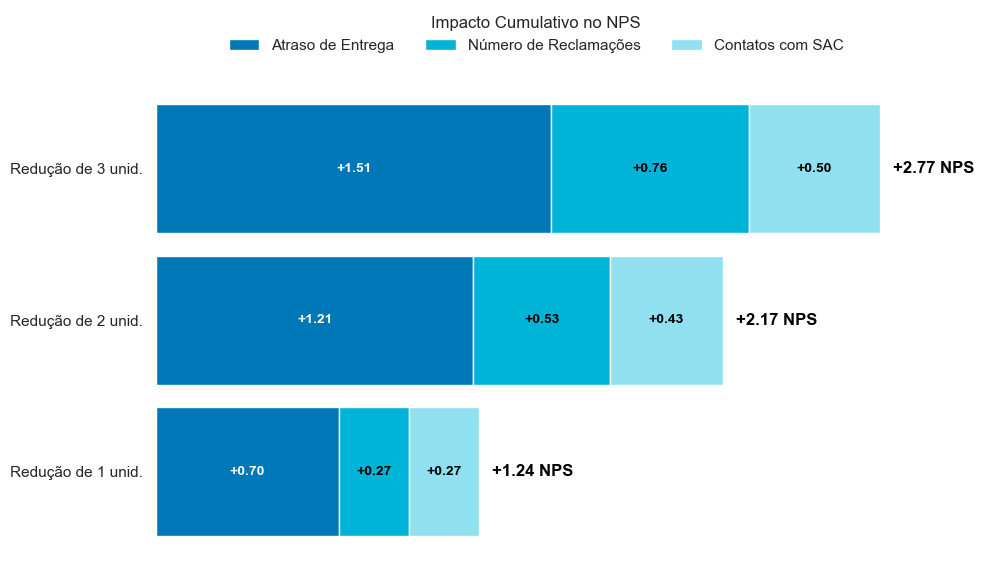

In [96]:
gerar_grafico_empilhado(lr, X_test, qtd_analisada=3)

#gerar_grafico_empilhado(gb, X_test, qtd_analisada=4) quis olhar a diferença do Gradient Boosting 

=== RESULTADOS DA SIMULAÇÃO: Cenário Combinado (Atraso + SAC) ===
NPS Original projetado: -82.6
NPS Pós-Simulação: -44.4
GANHO NO NPS FINAL: +38.2 pontos
Detratores (notas 0-6): caiu de 86.0% para 51.6%
Promotores (notas 9-10): subiu de 3.4% para 7.2%


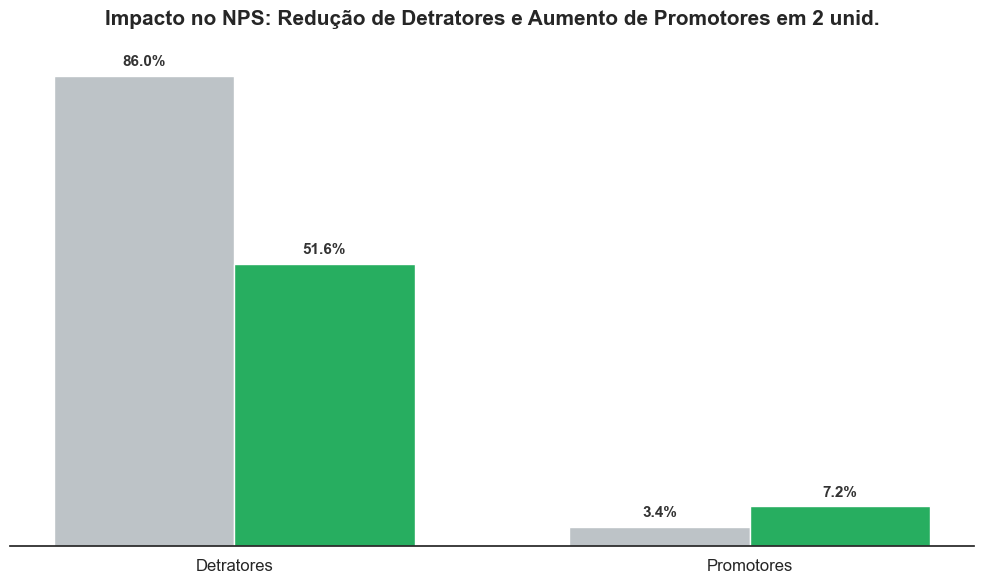

In [97]:
# Vamos criar um "Cenário Otimista" atacando duas frentes juntas:
unidades_de_melhora = 2 

cenario_logistica_sac = {
    'delivery_delay_days': unidades_de_melhora,        # Menos 2 dias de atraso
    'customer_service_contacts': unidades_de_melhora, # Menos 2 contatos no SAC
 #   'complaints_count': 2   # Numero de reclamações reduzido em 2, mas optei por manter essa variavel sem utilização por que ela parece ser resultado das outras duas
 #    inclusive acho que vale a pena fazer uma avaliação de correlação dessa variavel com o atraso e numero de contatos, deve ser grande
 #    mas a essa altura eu preferi ficar com o que tenho, caso contrario nunca vou terminar essa analise 
 #    mas deixo aqui a anotação pra quem sabe no futuro voltar e fazer essa visualização...
}

resultado_combinado = simular_nps_cenario_combinado(lr, X_test, cenario_logistica_sac)

print("=== RESULTADOS DA SIMULAÇÃO: Cenário Combinado (Atraso + SAC) ===")
print(f"NPS Original projetado: {resultado_combinado['nps_original']:.1f}")
print(f"NPS Pós-Simulação: {resultado_combinado['nps_simulado']:.1f}")
print(f"GANHO NO NPS FINAL: +{resultado_combinado['ganho_pontos_nps']:.1f} pontos")

print(f"Detratores (notas 0-6): caiu de {resultado_combinado['detratores_antes']:.1f}% para {resultado_combinado['detratores_depois']:.1f}%")
print(f"Promotores (notas 9-10): subiu de {resultado_combinado['promotores_antes']:.1f}% para {resultado_combinado['promotores_depois']:.1f}%")



# Novamente os neutros nao aparecem no gráfico, o modelo não é bom em fazer essa previsão, porém o nosso foco é promotores e detratores 

resultado_combinado = simular_nps_cenario_combinado(lr, X_test, cenario_logistica_sac)
plotar_comparacao_nps(resultado_combinado,unidades_de_melhora)


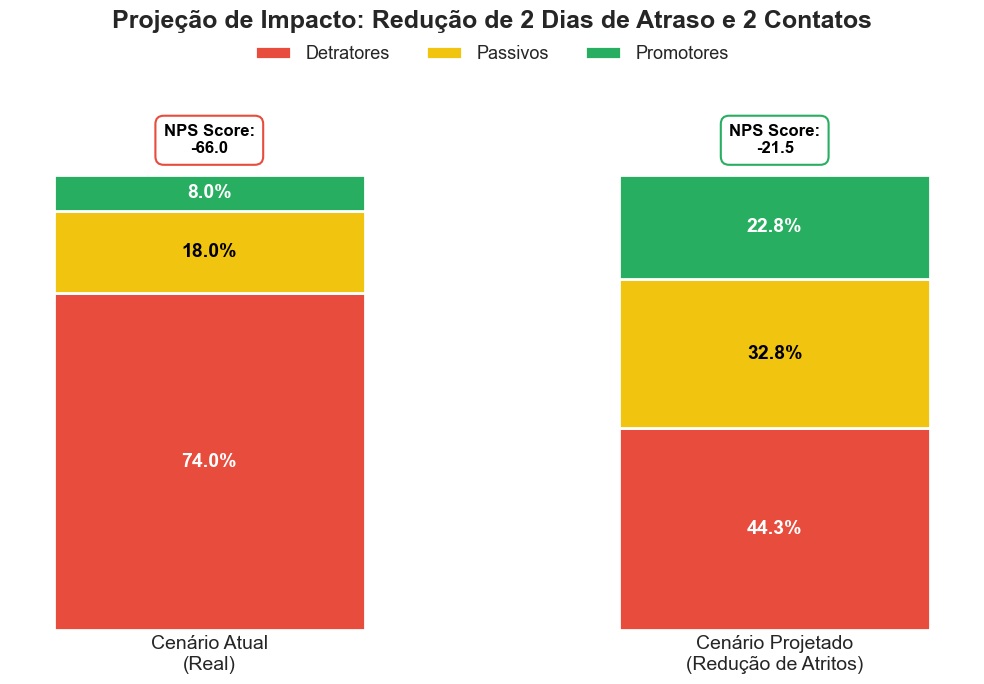

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 1. Os dados da VIDA REAL
detratores_real = 74.0  
promotores_real = 8.0 
passivos_real = 100.0 - detratores_real - promotores_real  

#tratamento de detratores e passivos em proporção ao encontrado no modelo
taxa_reducao_detratores = (86.0 - 51.5) / 86.0  
detratores_projetado = detratores_real * (1 - taxa_reducao_detratores)
detratores_curados = detratores_real - detratores_projetado
passivos_projetado = passivos_real + (detratores_curados * 0.5)
promotores_projetado = promotores_real + (detratores_curados * 0.5)

#Preparando os dados para plotagem
cenarios = ['Cenário Atual\n(Real)', 'Cenário Projetado\n(Redução de Atritos)']
detratores_plot = [detratores_real, detratores_projetado]
passivos_plot = [passivos_real, passivos_projetado]
promotores_plot = [promotores_real, promotores_projetado]

# Desenhando o Gráfico
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

# Barra Vermelha (Base)
b1 = ax.bar(cenarios, detratores_plot, color='#E74C3C', width=0.55, edgecolor='white', linewidth=2, label='Detratores')
# Barra Amarela (Meio)
b2 = ax.bar(cenarios, passivos_plot, bottom=detratores_plot, color='#F1C40F', width=0.55, edgecolor='white', linewidth=2, label='Passivos')
# Barra Verde (Topo)
bottom_promotores = [detratores_plot[i] + passivos_plot[i] for i in range(2)]
b3 = ax.bar(cenarios, promotores_plot, bottom=bottom_promotores, color='#27AE60', width=0.55, edgecolor='white', linewidth=2, label='Promotores')

#Adicionando os textos (%) dentro das barras
for i in range(2):
    ax.text(i, detratores_plot[i]/2, f'{detratores_plot[i]:.1f}%', ha='center', va='center', color='white', fontweight='bold', fontsize=14)
    ax.text(i, detratores_plot[i] + passivos_plot[i]/2, f'{passivos_plot[i]:.1f}%', ha='center', va='center', color='black', fontweight='bold', fontsize=14)
    ax.text(i, bottom_promotores[i] + promotores_plot[i]/2, f'{promotores_plot[i]:.1f}%', ha='center', va='center', color='white', fontweight='bold', fontsize=14)

# Adicionando o Score NPS no Topo de cada barra

nps_real = promotores_real - detratores_real
nps_projetado = promotores_projetado - detratores_projetado

ax.text(0, 104, f'NPS Score:\n{nps_real:.1f}', ha='center', va='bottom', color='black', fontweight='bold', fontsize=12, 
        bbox=dict(facecolor='white', edgecolor='#E74C3C', boxstyle='round,pad=0.5', linewidth=1.5))
ax.text(1, 104, f'NPS Score:\n{nps_projetado:.1f}', ha='center', va='bottom', color='black', fontweight='bold', fontsize=12, 
        bbox=dict(facecolor='white', edgecolor='#27AE60', boxstyle='round,pad=0.5', linewidth=1.5))

# Limpeza e Título
ax.set_title('Projeção de Impacto: Redução de 2 Dias de Atraso e 2 Contatos', fontsize=18, fontweight='bold', pad=40)
sns.despine(left=True, bottom=True)
ax.get_yaxis().set_visible(False)
ax.tick_params(axis='x', length=0, labelsize=14)

# Legenda centralizada no topo
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.10), ncol=3, frameon=False, fontsize=13)

ax.set_ylim(0, 120)
plt.tight_layout()
target_dir = Path("../docs/images")
target_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(target_dir / "nps_projecao_melhorada.png", transparent=True, bbox_inches='tight', dpi=300)

plt.show()



=== RESULTADOS DA SIMULAÇÃO: Cenário Combinado (Atraso + SAC) ===
NPS Original projetado: -84.4
NPS Pós-Simulação: -70.2
GANHO NO NPS FINAL: +14.2 pontos
Detratores (notas 0-6): caiu de 86.6% para 74.4%
Promotores (notas 9-10): subiu de 2.2% para 4.2%


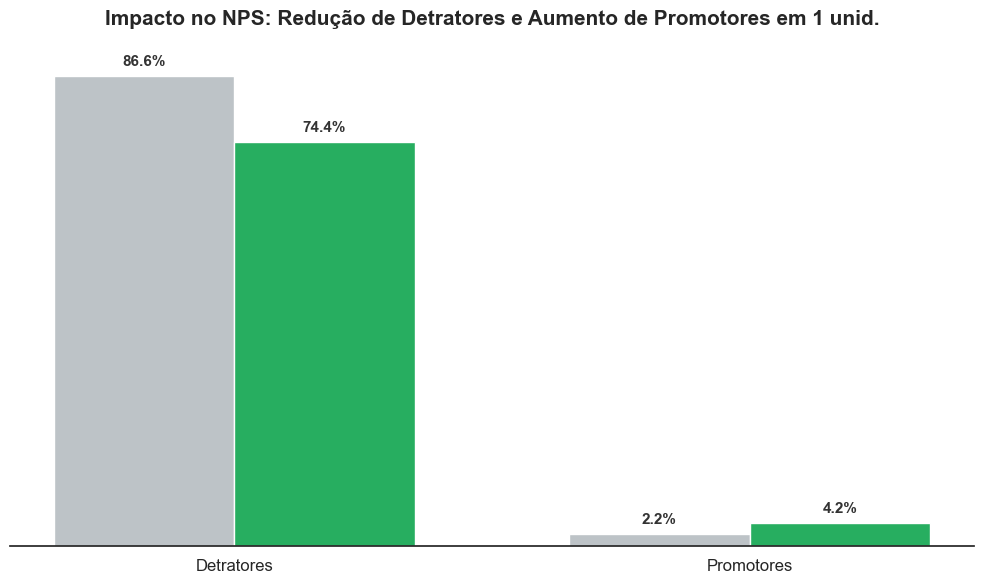

In [99]:
#
unidades_de_melhora = 1

cenario_logistica_sac = {
    'delivery_delay_days': unidades_de_melhora,        # Menos 2 dias de atraso
    'customer_service_contacts': unidades_de_melhora, # Menos 2 contatos no SAC
    'complaints_count': unidades_de_melhora  # Numero de reclamações reduzido em 2, mas optei por manter essa variavel sem utilização por que ela parece ser resultado das outras duas

}



resultado_combinado = simular_nps_cenario_combinado(gb, X_test, cenario_logistica_sac)

print("=== RESULTADOS DA SIMULAÇÃO: Cenário Combinado (Atraso + SAC) ===")
print(f"NPS Original projetado: {resultado_combinado['nps_original']:.1f}")
print(f"NPS Pós-Simulação: {resultado_combinado['nps_simulado']:.1f}")
print(f"GANHO NO NPS FINAL: +{resultado_combinado['ganho_pontos_nps']:.1f} pontos")

print(f"Detratores (notas 0-6): caiu de {resultado_combinado['detratores_antes']:.1f}% para {resultado_combinado['detratores_depois']:.1f}%")
print(f"Promotores (notas 9-10): subiu de {resultado_combinado['promotores_antes']:.1f}% para {resultado_combinado['promotores_depois']:.1f}%")



# Novamente os neutros nao aparecem no gráfico, o modelo não é bom em fazer essa previsão, porém o nosso foco é promotores e detratores 

resultado_combinado = simular_nps_cenario_combinado(gb, X_test, cenario_logistica_sac)
plotar_comparacao_nps(resultado_combinado,unidades_de_melhora)


In [100]:

y_train_pred = lr.predict(X_train)
# avaliar("Baseline", y_test, y_baseline)
# avaliar("Linear Regression - treino", y_train, y_train_pred)
# avaliar("Linear Regression Teste", y_test, y_pred_lr)
avaliar("Random Forest", y_test, y_pred_rf)
# avaliar("Gradient Boosting", y_test, y_pred_gb)
# avaliar("XGBoost", y_test, y_pred_xgb)


=== Random Forest ===
MAE:  1.230
RMSE: 1.528
R²:   0.631


In [101]:
print(f"MAE:  {mean_absolute_error(y_test, y_pred_rf):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.3f}")
print(f"R²:   {r2_score(y_test, y_pred_rf):.3f}")

MAE:  1.230
RMSE: 1.528
R²:   0.631


In [102]:
mean_absolute_error(y_test, y_pred_rf)

1.2302162766939775